# Notebook for calculating APWP from the VGP compilation and using the method of Gallo et al., 2023 to propagate uncertainty through the path

## import Python libraries

In [100]:
import ast 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pmagpy import ipmag, pmag
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm

from matplotlib.colors import Normalize, colorConverter
from matplotlib.cm import ScalarMappable

import seaborn as sns
import scipy.stats as st

import cartopy
import cartopy.crs as ccrs

from vgptools.utils import *
from vgptools.utils_visualization import *
from vgptools.utils_classes import *
from vgptools.utils_APWPs import *

%matplotlib inline
%config InlineBackend.figure_formats = 'retina'

## import site-level compilation data

In [101]:
Keweenawan_track_site_data_w_MAD_conversion = pd.read_csv('../data/pmag_compiled/Keweenawan_track_sites_w_MAD_conversion.csv')
Keweenawan_track_site_data_wo_MAD_conversion = pd.read_csv('../data/pmag_compiled/Keweenawan_track_sites_wo_MAD_conversion.csv')
Keweenawan_track_site_data_w_MAD_filter = pd.read_csv('../data/pmag_compiled/Keweenawan_track_sites_w_MAD_filter.csv')

print(f"Number of sites (w MAD conversion): {len(Keweenawan_track_site_data_w_MAD_conversion)}")
print(f"Number of sites (wo MAD conversion): {len(Keweenawan_track_site_data_wo_MAD_conversion)}")
print(f"Number of sites (w MAD filter): {len(Keweenawan_track_site_data_w_MAD_filter)}")

Number of sites (w MAD conversion): 990
Number of sites (wo MAD conversion): 990
Number of sites (w MAD filter): 877


In [102]:
Keweenawan_track_site_data_w_MAD_filter['geologic_classes'].unique()

<StringArray>
['Extrusive:Igneous', 'Intrusive:Igneous', 'Sedimentary']
Length: 3, dtype: str

In [103]:
Keweenawan_track_site_data_w_MAD_conversion['pole_name'].unique()

<StringArray>
[                           'Osler reverse lower',
                            'Osler reverse upper',
                                   'Osler normal',
                              'Mamainse lower R1',
                              'Mamainse lower R2',
                          'Mamainse lower normal',
                          'Mamainse upper normal',
                          'Grand Portage Basalts',
 'North Shore Volcanic Group (upper NE sequence)',
 'North Shore Volcanic Group (upper SW sequence)',
                       'Schroeder Lutsen Basalts',
                         'Portage Lake Volcanics',
                               'Lake Shore Traps',
                    'Powder Mill Group Volcanics',
       'Quebec Mine Member (Michipicoten Island)',
                  'Michipicoten Island Formation',
                                         'SWLLIP',
                                 'Duluth Complex',
                           'Beaver River diabase',
                 

In [104]:
# use leave-one-out method to see if it is the CutFace, Freda, or the Nonesuch that causes the high rates near ca 1085 Ma

Keweenawan_track_site_data_w_MAD_conversion_no_CutFace = Keweenawan_track_site_data_w_MAD_conversion[Keweenawan_track_site_data_w_MAD_conversion['pole_name'] != 'Cut Face Creek Sandstone'].reset_index(drop=True)

Keweenawan_track_site_data_w_MAD_conversion_no_Freda = Keweenawan_track_site_data_w_MAD_conversion[Keweenawan_track_site_data_w_MAD_conversion['pole_name'] != 'Freda Formation'].reset_index(drop=True)

Keweenawan_track_site_data_w_MAD_conversion_no_Nonesuch = Keweenawan_track_site_data_w_MAD_conversion[Keweenawan_track_site_data_w_MAD_conversion['pole_name'] != 'Nonesuch Formation'].reset_index(drop=True)

Keweenawan_track_site_data_w_MAD_conversion_no_Oronto = Keweenawan_track_site_data_w_MAD_conversion[(Keweenawan_track_site_data_w_MAD_conversion['pole_name'] != 'Freda Formation') & (Keweenawan_track_site_data_w_MAD_conversion['pole_name'] != 'Nonesuch Formation')].reset_index(drop=True)


In [105]:
Keweenawan_track_site_data_w_MAD_conversion

,pole_name,citations,location,site,lat,lon,age,age_high,age_low,age_unit,...,lithologies,geologic_types,age_model,height_type,height,height_upper,height_lower,paleolatitude,Plon,Plat
0,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(11.8 to 26.4),48.8122,272.3380,1108.0,1110.00,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,11.8,NaN,NaN,-54.692457,229.588330,33.098356
1,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(116.3 to 118.8),48.8062,272.3366,1108.0,1110.00,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,116.3,NaN,NaN,-54.393410,231.831739,30.447349
2,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(119.7 to 122.1),48.8060,272.3366,1108.0,1110.00,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,119.7,NaN,NaN,-52.341346,223.912252,35.321456
3,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(122.1 to 123.7),48.8058,272.3367,1108.0,1110.00,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,122.1,NaN,NaN,-52.630096,229.585495,29.952660
4,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(28.3 to 29.2),48.8107,272.3377,1108.0,1110.00,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,28.3,NaN,NaN,-49.396782,210.954452,45.769076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,Nonesuch Formation,"Henry, 1977",Presque Isle River,33,46.6680,-89.9400,1080.0,1085.57,1075.00,Ma,...,Shale,Sediment Layer,Oronto Group,exact,1950.0,NaN,NaN,13.471886,175.379813,23.024456
986,Freda Formation,"Henry, 1977",Presque Isle River,34,46.6720,-89.9400,1070.0,1075.00,1050.00,Ma,...,Sandstone,Sediment Layer,Oronto Group,exact,2078.0,NaN,NaN,0.800156,194.743613,-12.377273
987,Freda Formation,"Henry, 1977",Presque Isle River,35,46.6740,-89.9400,1070.0,1075.00,1050.00,Ma,...,Sandstone,Sediment Layer,Oronto Group,exact,2123.0,NaN,NaN,2.756350,186.976630,-2.714175
988,Nonesuch Formation,"Henry, 1977",Silver City,40,46.8320,-89.5720,1080.0,1085.57,1075.00,Ma,...,Shale,Sediment Layer,Oronto Group,exact,2065.0,NaN,NaN,9.768497,174.426407,18.987796


## load age models

In [106]:
Keweenawan_track_site_data_w_MAD_conversion['age_model'].unique()

<StringArray>
[         'Osler Volcanic Group',                             nan,
      'Mamainse Point Volcanics', 'North Shore Volcanic Group NE',
 'North Shore Volcanic Group SW',        'Portage Lake Volcanics',
 'Michipicoten Island Formation',                'Cut Face Creek',
                  'Oronto Group']
Length: 9, dtype: str

In [107]:
all_section_names = ['Osler Volcanic Group', 'Mamainse Point Volcanics',
       'North Shore Volcanic Group NE', 'North Shore Volcanic Group SW',
       'Portage Lake Volcanics', 'Michipicoten Island Formation',
       'Cut Face Creek', 'Oronto Group']
all_age_model_paths = ['../data/age_models_output/Osler_Volcanic_Group_posterior_ages.csv',
                       '../data/age_models_output/Mamainse_Point_Volcanic_Group_posterior_ages.csv',
                       '../data/age_models_output/NSVG_NE_posterior_ages.csv',
                       '../data/age_models_output/NSVG_SW_posterior_ages.csv',
                       '../data/age_models_output/PLV_posterior_ages.csv',
                       '../data/age_models_output/Michipicoten_posterior_ages.csv',
                       '../data/age_models_output/Cut_Face_posterior_ages.csv',
                       '../data/age_models_output/Oronto_Group_posterior_ages.csv']
all_age_model_posteriors = [pd.read_csv(i) for i in all_age_model_paths]

age_model_posterior_df = pd.DataFrame({'posterior_age_model': all_age_model_posteriors}, index=all_section_names)
age_model_posterior_df

,posterior_age_model
Osler Volcanic Group,height x2 x3 ...
Mamainse Point Volcanics,height x2 x3 ...
North Shore Volcanic Group NE,height x2 x3 ...
North Shore Volcanic Group SW,height x2 x3 ...
Portage Lake Volcanics,height x2 x3 ...
Michipicoten Island Formation,height x2 x3 ...
Cut Face Creek,height x2 x3 ...
Oronto Group,height x2 x3 ...


## load f factors

In [108]:
# note that we use the same f factors for Freda and Nonesuch
all_seds_sections = ['Freda Formation', 'Nonesuch Formation', 'Cut Face Creek Sandstone']
all_seds_f_paths = ['../data/pmag_compiled/Slotznick2023/flattening_factors.csv', 
                    '../data/pmag_compiled/Slotznick2023/flattening_factors.csv', 
                    '../data/pmag_compiled/Pierce2022/flattening_factors.csv']
all_seds_f = [pd.read_csv(i, header=None) for i in all_seds_f_paths]

seds_f_df = pd.DataFrame({'f_factors': all_seds_f}, index=all_seds_sections)
seds_f_df

,f_factors
Freda Formation,0 0 0.968188 1 0.872105 2 ...
Nonesuch Formation,0 0 0.968188 1 0.872105 2 ...
Cut Face Creek Sandstone,0 0 0.994871 1 0.984513 2 ...


## construct the ultimate VGP resampling function

In [109]:
%%time
np.random.seed(2024)

n_sims = 100

CPU times: user 14 μs, sys: 11 μs, total: 25 μs
Wall time: 26.2 μs


### 1. resample the Keweenawan_track_site_data_w_MAD_conversion

In [110]:
df_ultimate_RM_ensemble_w_MAD, pseudo_ultimate_sites_ensemble_w_MAD = ultimate_ensemble_RMs_parallel(Keweenawan_track_site_data_w_MAD_conversion, age_model_posterior_df, seds_f_df, n_sims = n_sims, min_age=1075)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done  44 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  94 out of 100 | elapsed:    9.2s remaining:    0.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    9.6s finished


In [111]:
# for study in pseudo_ultimate_sites_ensemble_w_MAD['study'].unique():
#     plt.figure(figsize=(4,2))
#     plt.hist(pseudo_ultimate_sites_ensemble_w_MAD[pseudo_ultimate_sites_ensemble_w_MAD['study']==study]['age'], bins=20, color='skyblue', edgecolor=None)

#     plt.title(f"Age distribution for study: {study} (w MAD conversion)")
#     plt.xlabel("Age (Ma)")
#     plt.xticks(rotation=45)
#     plt.ylabel("Number of sites")
#     plt.gca().invert_xaxis()
#     plt.show()

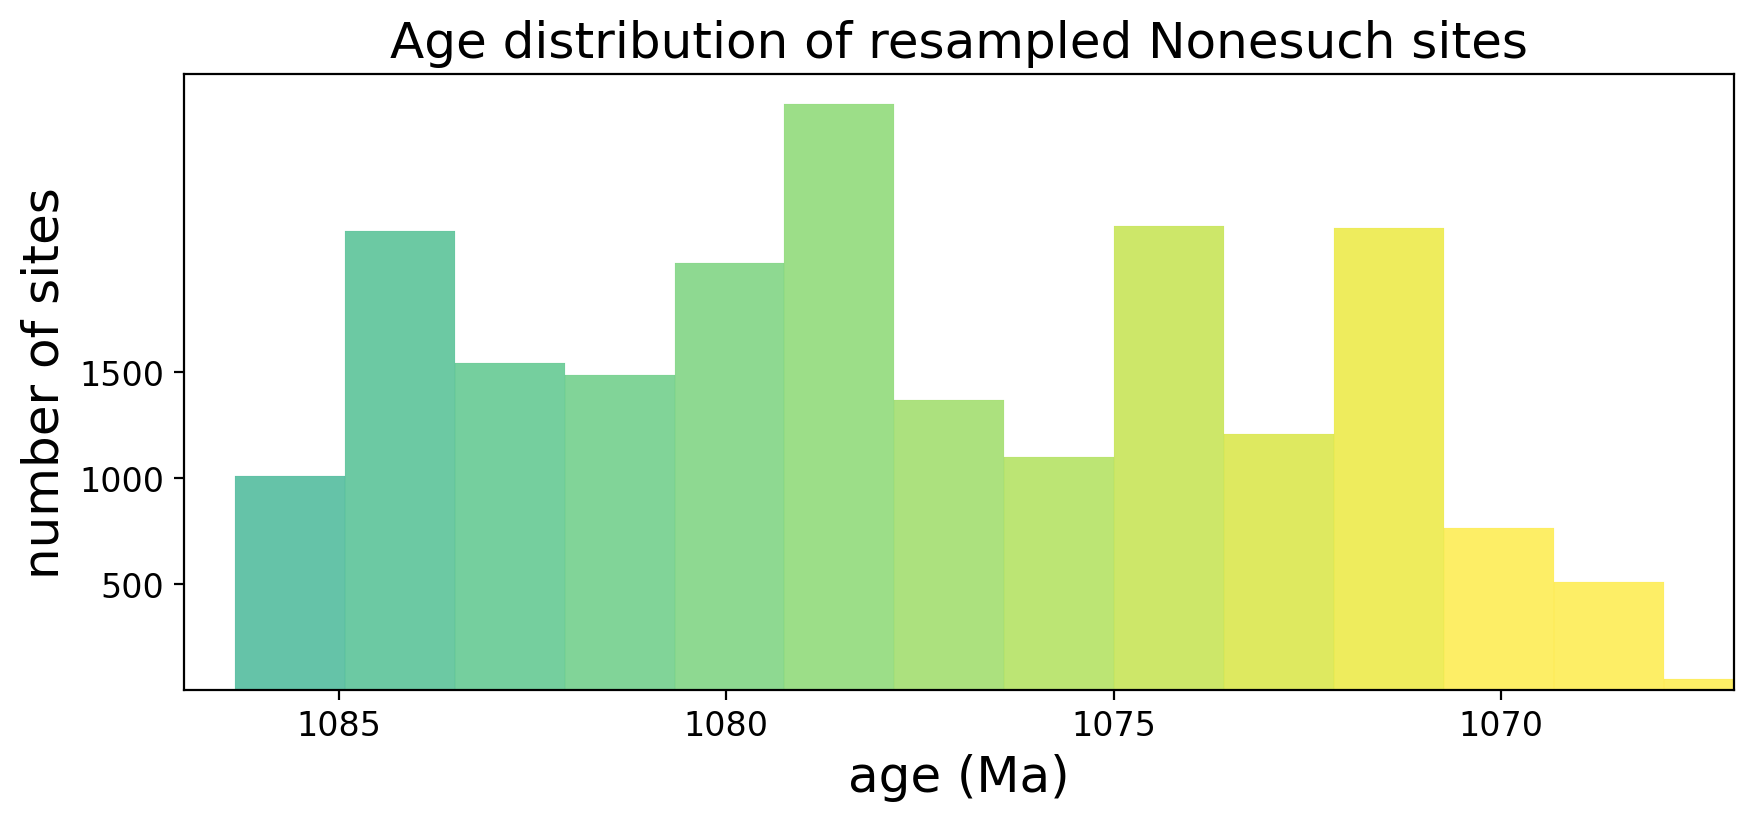

In [112]:
resampled_Oronto = pseudo_ultimate_sites_ensemble_w_MAD[(pseudo_ultimate_sites_ensemble_w_MAD['study']=='Nonesuch Formation') | (pseudo_ultimate_sites_ensemble_w_MAD['study']=='Freda Formation')]['age']

bins = 25
hist, bin_edges = np.histogram(resampled_Oronto, bins)
# Compute bin centers for coloring
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# Create a colormap based on the x-axis values (bin centers)
norm = Normalize(vmin=1070, vmax=1110)
cmap = plt.cm.viridis_r

# Plot the histogram
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(bins):
    ax.bar(bin_edges[i], hist[i], width=bin_edges[1]-bin_edges[0],
           color=cmap(norm(bin_centers[i])), align='edge', alpha=0.7, edgecolor=colorConverter.to_rgba(cmap(norm(bin_centers[i])), alpha=.0), lw=0.05)
    
# plt.gca().invert_xaxis()

# ax.set_yticks([])
plt.xlim(1087, 1067)
plt.xticks([1085, 1080, 1075, 1070], fontsize=12)
plt.yticks([500, 1000, 1500], fontsize=12)
ax.set_xlabel('age (Ma)', fontsize=18)
ax.set_ylabel('number of sites', fontsize=18)
plt.title('Age distribution of resampled Nonesuch sites', fontsize=18)
# plt.savefig('../figure/Nonesuch_site_age_hist.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

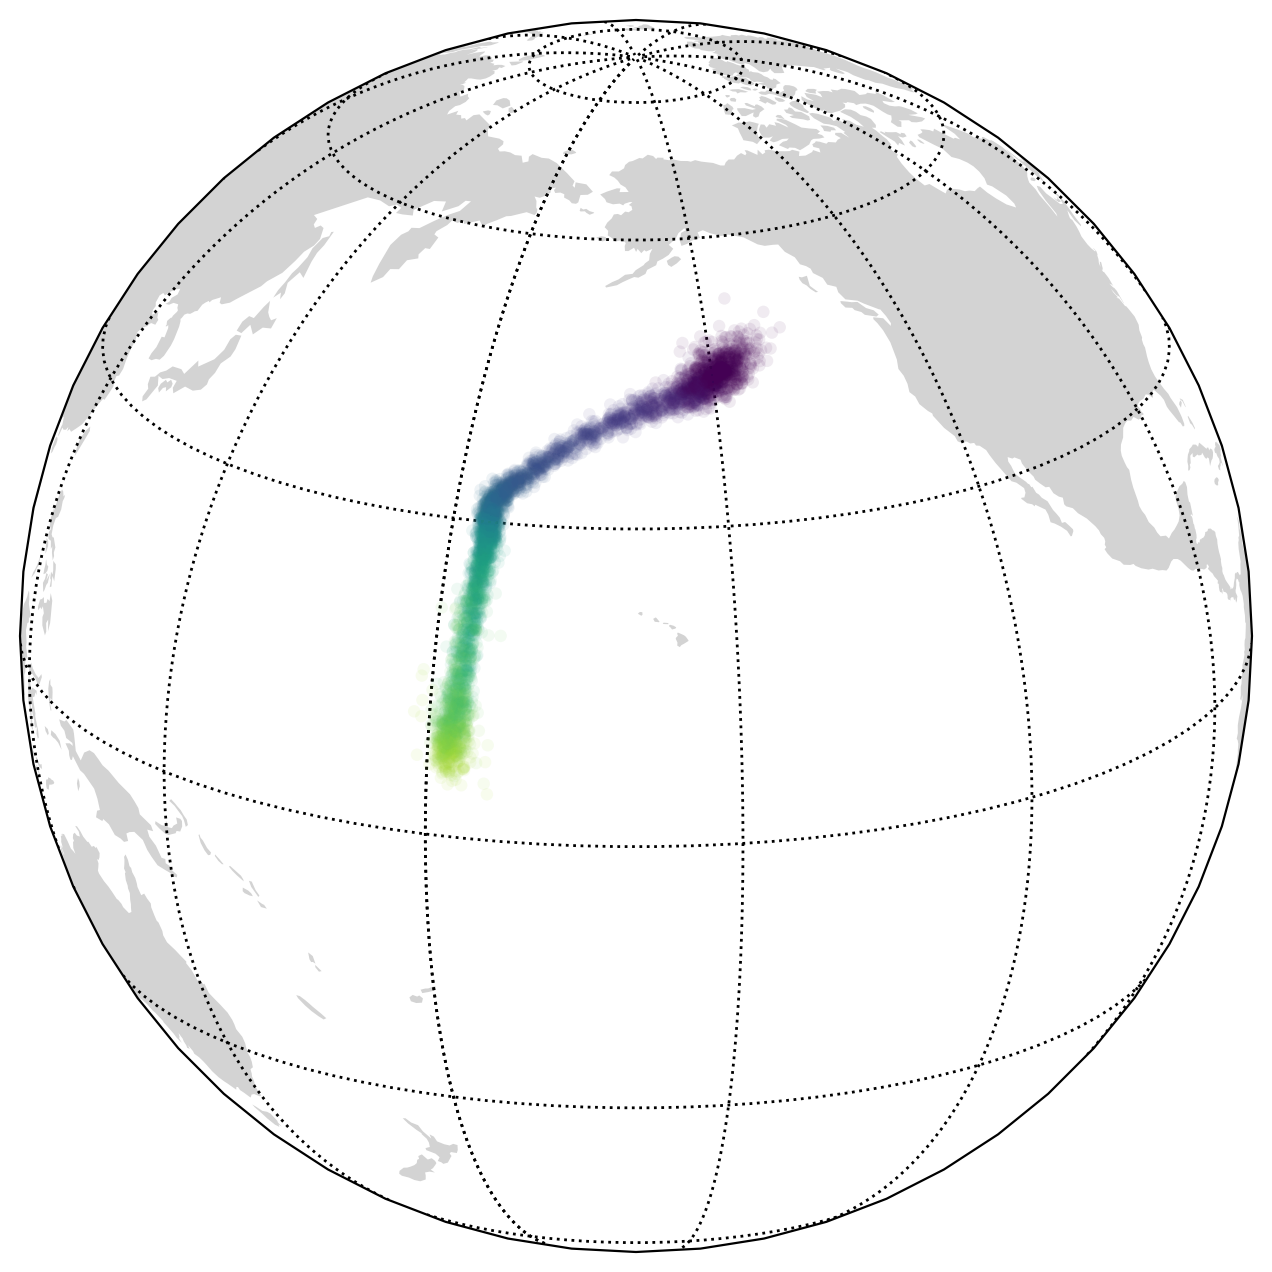

In [113]:
ax = ipmag.make_orthographic_map(200, 20, land_edge_color='none', land_color='lightgrey')
ipmag.plot_poles_colorbar(ax, df_ultimate_RM_ensemble_w_MAD['plon'], df_ultimate_RM_ensemble_w_MAD['plat'], 
                          np.zeros(df_ultimate_RM_ensemble_w_MAD.shape[0]), marker='o', 
                          colorvalues=df_ultimate_RM_ensemble_w_MAD['age'], vmin=1070, vmax=1110, 
                          colormap='viridis_r',
                          alpha=0.08, edgecolor='none', colorbar=0)
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_VGPs.png', dpi=300, bbox_inches='tight')

In [134]:
ultimate_ensemble_rates = pd.DataFrame()
for j in range(n_sims):
    df = pd.DataFrame()
    for i in [1070., 1075., 1080., 1085., 1090., 1095., 1100., 1105., 1110.]:
        pole = df_ultimate_RM_ensemble_w_MAD[df_ultimate_RM_ensemble_w_MAD['effective_age'] == i].sample(n=1)
        df = pd.concat([df, pole], ignore_index=True)
    # The following block calculates rate of polar wander (degrees per million years) 
    df['run'] = j
    df['PPcartesian'] = df.apply(lambda row: spherical2cartesian([np.radians(row['plat']),np.radians(row['plon'])]), axis = 1)
    df['PP_prev'] = df['PPcartesian'].shift(periods = 1)
    df['PP_next'] =  df['PPcartesian'].shift(periods = -1)
    df['GCD'] = df.apply(lambda row: np.degrees(GCD_cartesian(row['PP_prev'], row['PPcartesian'])), axis = 1)
    df['APW_rate'] = df['GCD']/df['effective_age'].diff()
    ultimate_ensemble_rates = pd.concat([ultimate_ensemble_rates, df], ignore_index=True)

# Set the level confidence at which we want to work 
quantile = 95

# Since the Latitude and Longitude covaries, we need to calculate the Principal component for each timre-dependant point Cloud 
# the class PC() has also methods to aid in the calculatrio
ensemble_PC_eff_age = PC(df_ultimate_RM_ensemble_w_MAD,"effective_age","plat","plon") # set principal component for each Age

# # Ensemble's parameters (e.g. Apparent polar wander rate, age difference)
ensemble_apw_eff = quantiles(df_ultimate_RM_ensemble_w_MAD,"effective_age", "APW_rate") # set quantiles of latitude groupedby age for visualization purposes
ensemble_apw_ef_ = quantiles(ultimate_ensemble_rates,"effective_age", "APW_rate") # set quantiles of latitude groupedby age for visualization purposes

ensemble_n_studies = quantiles(ultimate_ensemble_rates,"effective_age","n_studies")
ensemble_n_vgps = quantiles(ultimate_ensemble_rates,"effective_age","N")

#### calcualte average APWP rates

In [128]:
bins = 50
hist, bin_edges = np.histogram(pseudo_ultimate_sites_ensemble_w_MAD['age'], bins)
# Compute bin centers for coloring
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# Create a colormap based on the x-axis values (bin centers)
norm = Normalize(vmin=1060, vmax=1115)
cmap = plt.cm.viridis_r

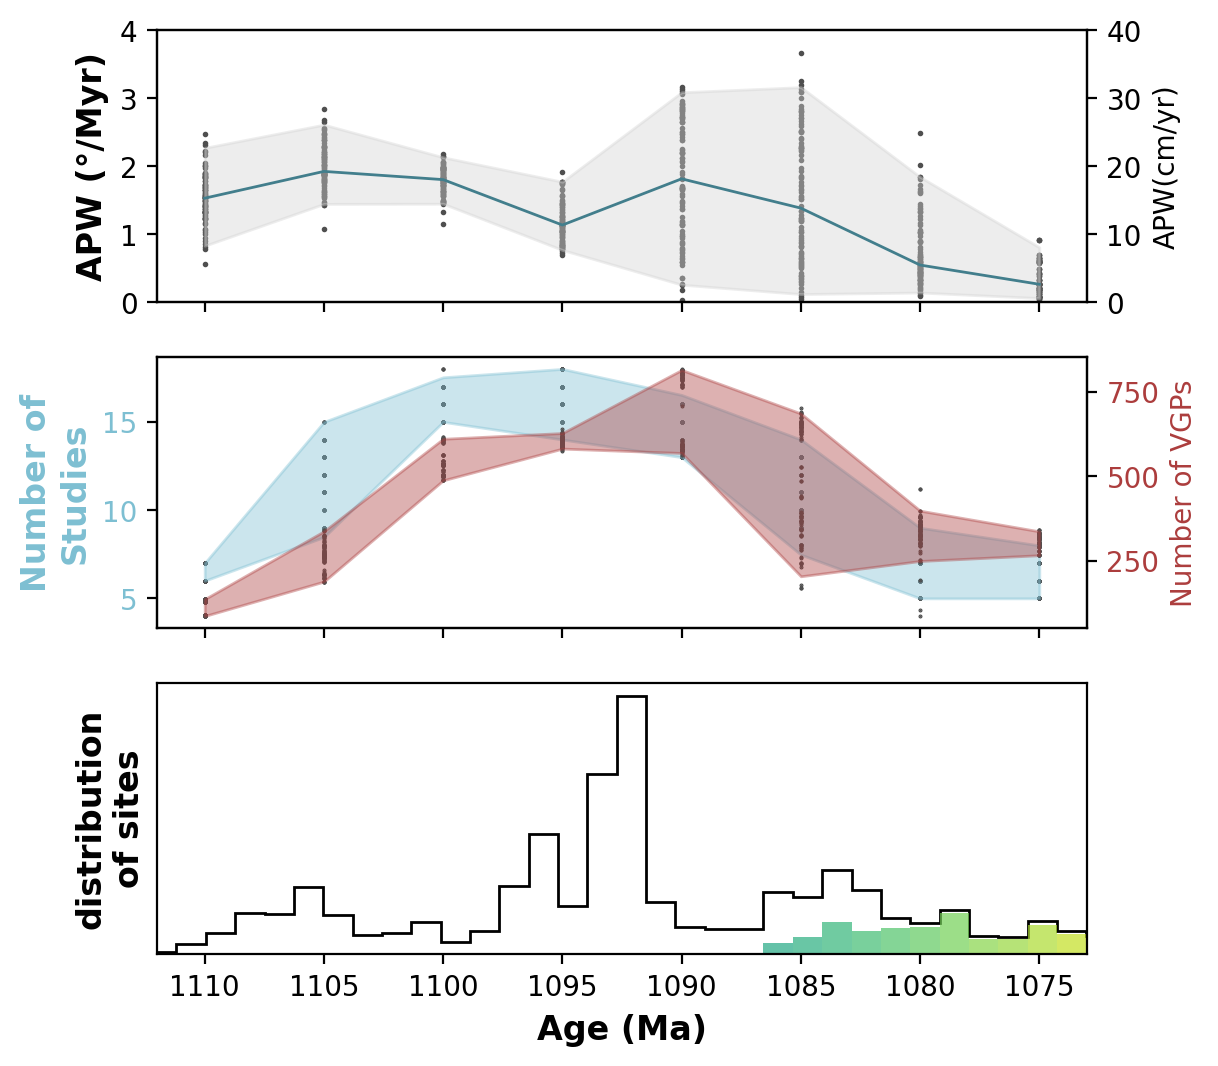

In [136]:
fig, axes = plt.subplots(3, 1, figsize=(6,6), sharex=True)

# Set Axis Labels
axes[0].set_ylabel(r'APW (°/Myr)', fontweight ='bold', fontsize = 12)
axes[1].set_ylabel('Number of\nStudies', fontweight ='bold', fontsize = 12, color="#7DBFD2")
axes[2].set_ylabel('distribution\nof sites', fontweight ='bold', fontsize = 12)
axes[2].set_yticks([])
axes[2].set_xlabel(r'Age (Ma)', fontweight ='bold', fontsize = 12)

# plot 50 runs to save computational cost and very dense graphics 
df_RM_ensemble_50 = df_ultimate_RM_ensemble_w_MAD[df_ultimate_RM_ensemble_w_MAD['run'].isin(range(0,100))]
# red = ##7F4141
for run, df_run in ultimate_ensemble_rates.groupby('effective_age'):
    axes[0].scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.APW_rate.to_numpy()[df_run.effective_age.to_numpy() > 2], color="#4F4F4F", zorder =0, s=1)
axes[0].fill_between(np.sort(ensemble_apw_ef_.X), ensemble_apw_ef_.q025, ensemble_apw_ef_.q975, color= "lightgrey", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
axes[0].plot(np.sort(ensemble_apw_ef_.X), ensemble_apw_ef_.q50,color="#427E8C", zorder =3, linewidth=1, label="Ensemble Median")
axes[0].set_ylim(0, 4.0)
axes[0].set_yticks([0, 1, 2, 3, 4])
ax1 = axes[0].twinx()
ax1.set_yticks([0, 1, 2, 3, 4], [0, 10, 20, 30, 40])
ax1.set_ylabel('APW(cm/yr)', color="k")

for run, df_run in ultimate_ensemble_rates.groupby('effective_age'):
    axes[1].scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.n_studies.to_numpy()[df_run.effective_age.to_numpy() > 2], color="#4F4F4F",  zorder =0, s=0.2)
axes[1].fill_between(np.sort(ensemble_n_studies.X)[1:], ensemble_n_studies.q025[1:],ensemble_n_studies.q975[1:], color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
axes[1].tick_params(axis='y', labelcolor="#7DBFD2")

ax2 = axes[1].twinx()  # instantiate a second axes that shares the same x-axis

for run, df_run in ultimate_ensemble_rates.groupby('effective_age'):
    ax2.scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.N.to_numpy()[df_run.effective_age.to_numpy() > 2], color="#4F4F4F",  zorder =0, s=0.2)
ax2.fill_between(np.sort(ensemble_n_vgps.X)[1:], ensemble_n_vgps.q025[1:],ensemble_n_vgps.q975[1:], color= "#ac3d3d", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
ax2.set_ylabel('Number of VGPs', color="#ac3d3d")
ax2.tick_params(axis='y', labelcolor="#ac3d3d")
ax2.grid(False)

# Plot the histogram
# Define shared bins
all_data = pseudo_ultimate_sites_ensemble_w_MAD['age']
all_data_bins = np.linspace(all_data.min(), all_data.max(), 51)

# Histogram 1
pseudo_ultimate_sites_ensemble_w_MAD['age'].hist(
    bins=all_data_bins,
    color='skyblue',
    edgecolor=None,
    ax=axes[2],
    histtype='step',
    zorder=0
)

# Histogram 2
resampled_Oronto = pseudo_ultimate_sites_ensemble_w_MAD[
    pseudo_ultimate_sites_ensemble_w_MAD['study']=='Nonesuch Formation'
]['age']

hist, bin_edges = np.histogram(resampled_Oronto, bins=all_data_bins)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
norm = Normalize(vmin=1070, vmax=1110)
cmap = plt.cm.viridis_r

for i in range(len(bin_edges) - 1):
    axes[2].bar(
        bin_edges[i],
        hist[i],
        width=bin_edges[i+1] - bin_edges[i],
        color=cmap(norm(bin_centers[i])),
        align='edge',
        alpha=0.7,
        edgecolor='none'
    )
axes[2].grid(False)


axes[0].set_xlim(1112, 1073)
axes[1].set_xlim(1112, 1073)
axes[2].set_xlim(1112, 1073)

plt.savefig('../figure/Keweenawan_ultimate_ensemble_stats.pdf', bbox_inches='tight')

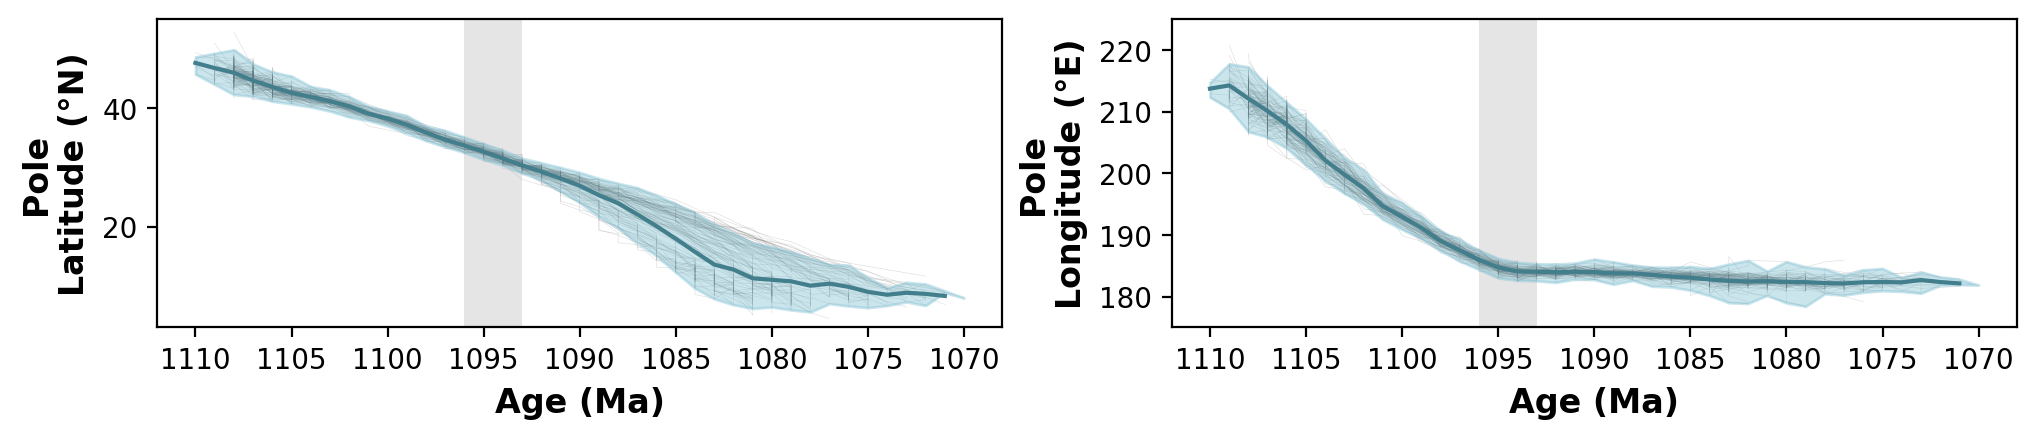

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(12,2), sharex=True)

# Set Axis Labels
axes[0].set_ylabel('Pole\nLatitude (°N)', fontweight ='bold', fontsize = 12)
axes[0].set_xlabel('Age (Ma)', fontweight ='bold', fontsize = 12)

axes[1].set_ylabel('Pole\nLongitude (°E)', fontweight ='bold', fontsize = 12)
axes[1].set_xlabel('Age (Ma)', fontweight ='bold', fontsize = 12)

# LATITUDES 
for run, df_run in df_RM_ensemble_50.groupby('run'):
    axes[0].plot(df_run.effective_age.tolist(), df_run.plat.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, alpha=0.2)

# axes[0].plot(df_run.effective_age.tolist(), df_run.plat.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, label = 'Moving Average realization')
axes[0].fill_between(ensemble_PC_eff_age.X, ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[2], 
                     ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[3], 
                     color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
# axes[0].scatter(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[1],color="#314B54", s = 15,  label = 'Principal component of the age ensemble')  
axes[0].plot(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[1],color="#427E8C")  

# LONGITUDES     
for run, df_run in df_RM_ensemble_50.groupby('run'):
    axes[1].plot(df_run.effective_age.tolist(), df_run.plon.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, alpha=0.2)
# axes[1].plot(df_run.effective_age.tolist(), df_run.plon.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, label = 'Moving Average realization')
axes[1].fill_between(ensemble_PC_eff_age.X, ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[0], 
                     ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[1], 
                     color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
# axes[1].scatter(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[0]%360,color="#314B54", s = 15,  label = 'Principal component of the age ensemble')
axes[1].plot(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[0]%360,color="#427E8C")  

axes[0].fill_between([1093, 1096], [3,3], [55, 55], color='grey', lw=0, alpha=0.2, zorder=0)
axes[0].set_ylim(3, 55)

axes[1].fill_between([1093, 1096], [175,175], [225, 225], color='grey', lw=0, alpha=0.2, zorder=0)
axes[1].set_ylim(175, 225)


plt.gca().invert_xaxis()
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_APW_components.pdf', bbox_inches='tight')


### 5. resample the Keweenawan_track_site_data_w_MAD_conversion_no_Oronto

In [118]:
n_sims = 100

In [119]:
df_ultimate_RM_ensemble_w_MAD_no_Oronto, pseudo_ultimate_sites_ensemble_w_MAD_no_Oronto = ultimate_ensemble_RMs_parallel(Keweenawan_track_site_data_w_MAD_conversion_no_Oronto, age_model_posterior_df, seds_f_df, n_sims = n_sims, min_age=1075)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 14 concurrent workers.


[Parallel(n_jobs=-1)]: Done  44 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done  94 out of 100 | elapsed:    7.8s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    8.0s finished


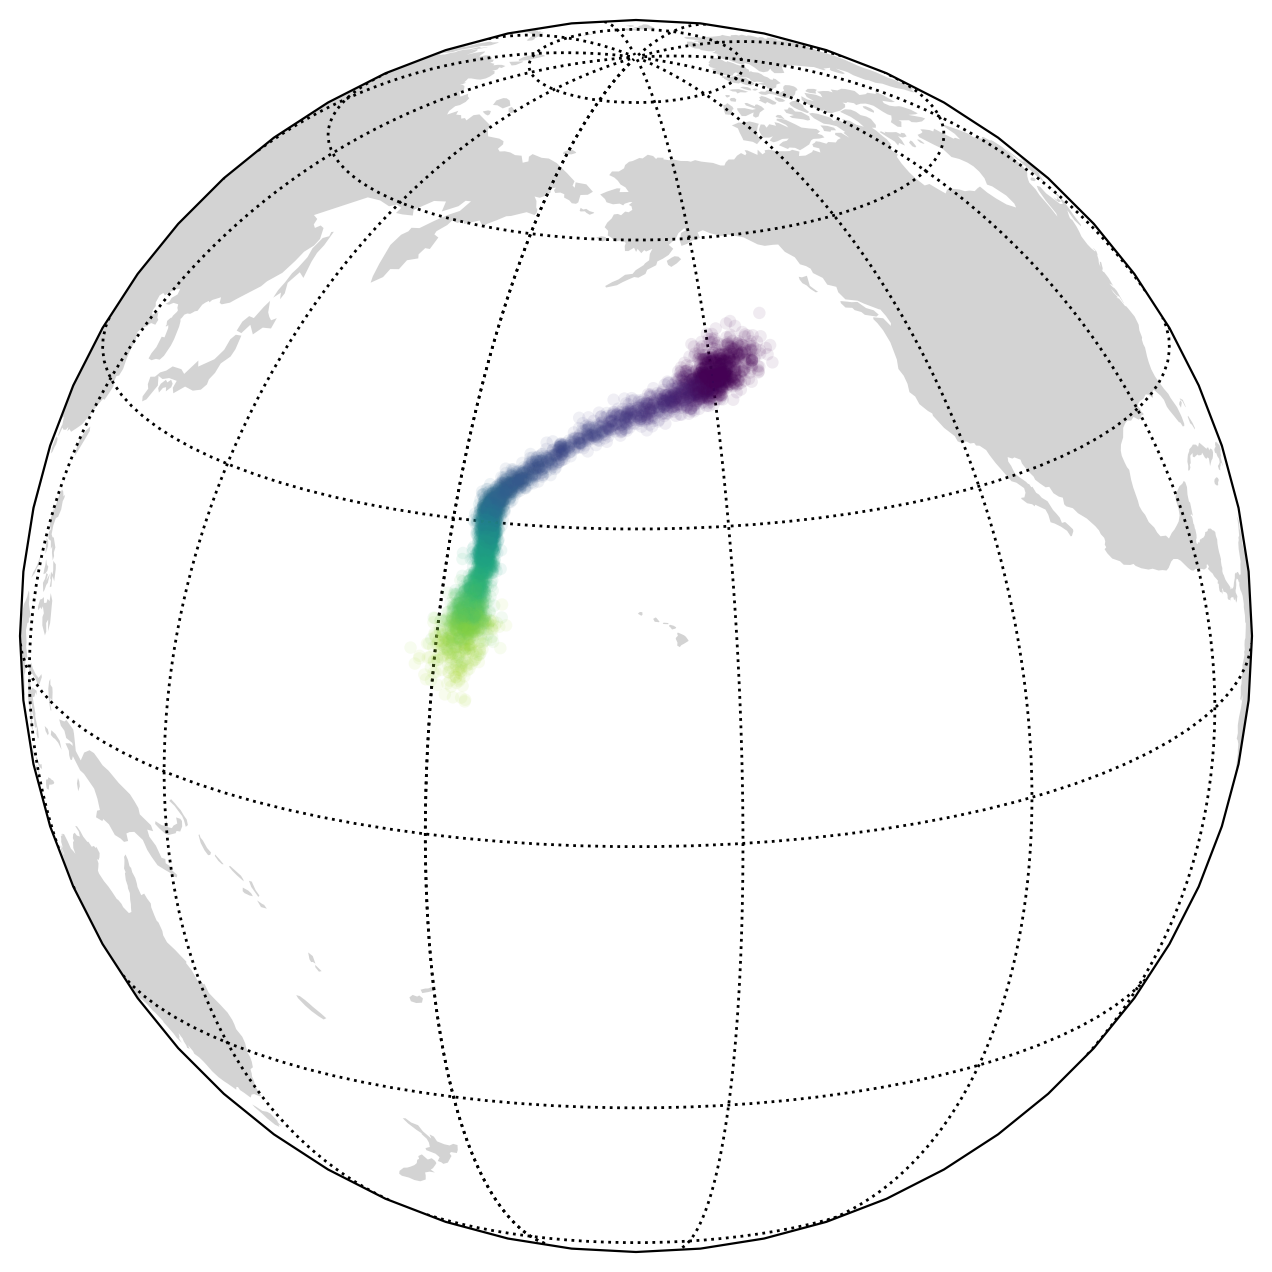

In [120]:
ax = ipmag.make_orthographic_map(200, 20, land_edge_color='none', land_color='lightgrey')
ipmag.plot_poles_colorbar(ax, df_ultimate_RM_ensemble_w_MAD_no_Oronto['plon'], 
                          df_ultimate_RM_ensemble_w_MAD_no_Oronto['plat'], 
                          np.zeros(df_ultimate_RM_ensemble_w_MAD_no_Oronto.shape[0]), marker='o', 
                          colorvalues=df_ultimate_RM_ensemble_w_MAD_no_Oronto['age'], vmin=1070, vmax=1110, 
                          colormap='viridis_r', alpha=0.08, edgecolor='none', colorbar=0)
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_VGPs.png', dpi=300, bbox_inches='tight')

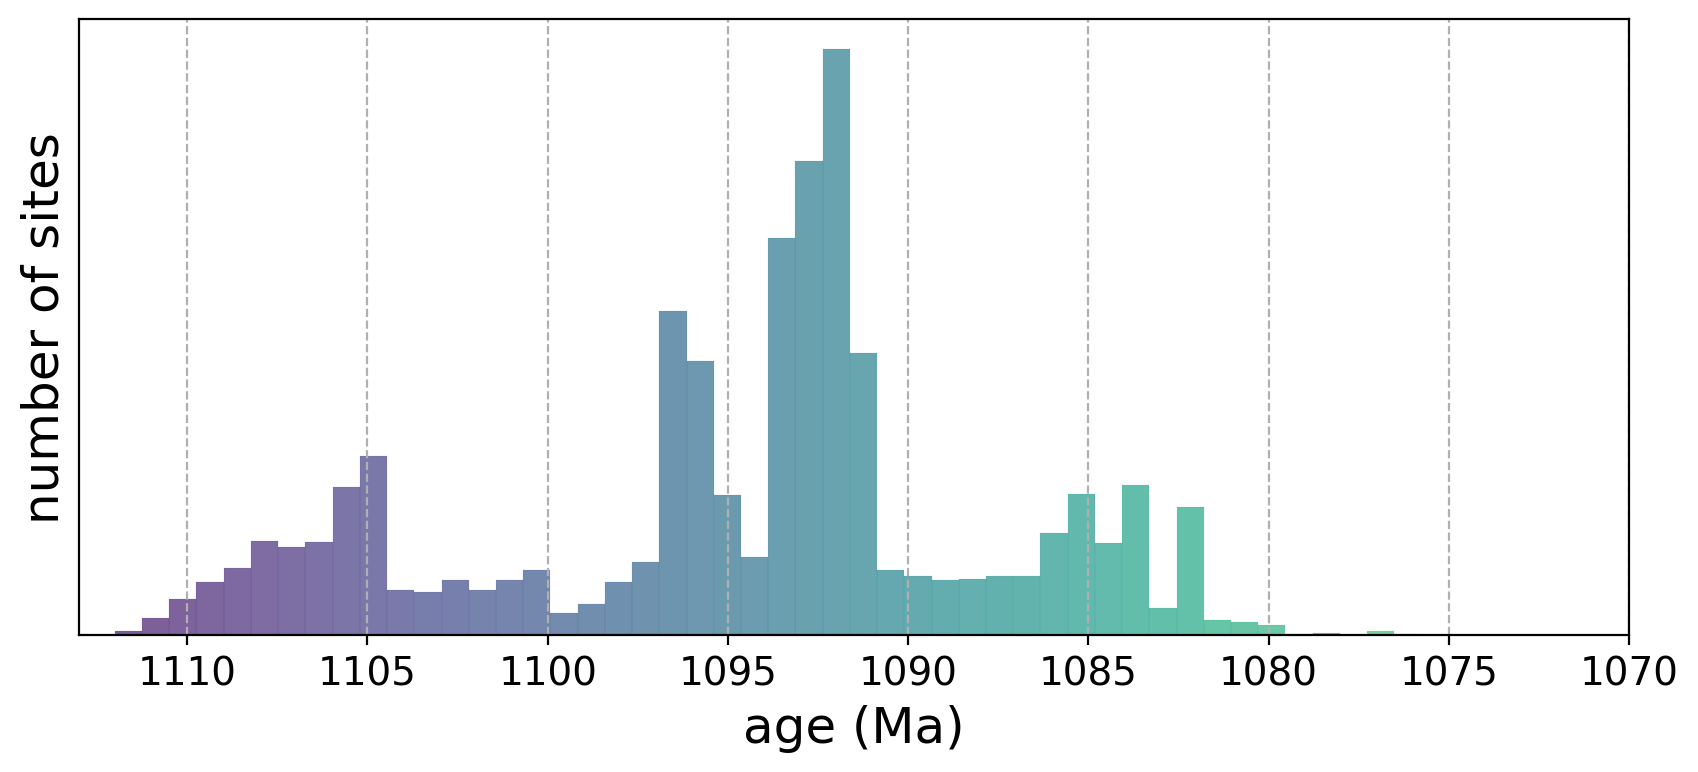

In [121]:
bins = 50
hist, bin_edges = np.histogram(pseudo_ultimate_sites_ensemble_w_MAD_no_Oronto['age'], bins)
# Compute bin centers for coloring
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# Create a colormap based on the x-axis values (bin centers)
norm = Normalize(vmin=1060, vmax=1115)
cmap = plt.cm.viridis_r

# Plot the histogram
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(bins):
    ax.bar(bin_edges[i], hist[i], width=bin_edges[1]-bin_edges[0],
           color=cmap(norm(bin_centers[i])), align='edge', alpha=0.7, edgecolor=colorConverter.to_rgba(cmap(norm(bin_centers[i])), alpha=.0), lw=0.05)
    
plt.gca().invert_xaxis()
plt.grid(True, ls='--')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_visible(False)
ax.set_yticks([])
plt.xlim(1113, 1070)
plt.xticks(fontsize=14)
ax.set_xlabel('age (Ma)', fontsize=18)
ax.set_ylabel('number of sites', fontsize=18)
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_site_age_hist_no_Oronto.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [130]:
ultimate_ensemble_rates = pd.DataFrame()
for j in range(n_sims):
    df = pd.DataFrame()
    for i in [1080., 1085., 1090., 1095., 1100., 1105., 1110.]:
        pole = df_ultimate_RM_ensemble_w_MAD_no_Oronto[df_ultimate_RM_ensemble_w_MAD_no_Oronto['effective_age'] == i].sample(n=1)
        df = pd.concat([df, pole], ignore_index=True)
    # The following block calculates rate of polar wander (degrees per million years) 
    df['run'] = j
    df['PPcartesian'] = df.apply(lambda row: spherical2cartesian([np.radians(row['plat']),np.radians(row['plon'])]), axis = 1)
    df['PP_prev'] = df['PPcartesian'].shift(periods = 1)
    df['PP_next'] =  df['PPcartesian'].shift(periods = -1)
    df['GCD'] = df.apply(lambda row: np.degrees(GCD_cartesian(row['PP_prev'], row['PPcartesian'])), axis = 1)
    df['APW_rate'] = df['GCD']/df['effective_age'].diff()
    ultimate_ensemble_rates = pd.concat([ultimate_ensemble_rates, df], ignore_index=True)

# Set the level confidence at which we want to work 
quantile = 95

# Since the Latitude and Longitude covaries, we need to calculate the Principal component for each timre-dependant point Cloud 
# the class PC() has also methods to aid in the calculatrio
ensemble_PC_eff_age = PC(df_ultimate_RM_ensemble_w_MAD_no_Oronto,"effective_age","plat","plon") # set principal component for each Age

# Ensemble's parameters (e.g. Apparent polar wander rate, age difference)
ensemble_apw_eff = quantiles(df_ultimate_RM_ensemble_w_MAD_no_Oronto,"effective_age","APW_rate") # set quantiles of latitude groupedby age for visualization purposes
ensemble_apw_ef_ = quantiles(ultimate_ensemble_rates,"effective_age","APW_rate") # set quantiles of latitude groupedby age for visualization purposes

ensemble_n_studies = quantiles(ultimate_ensemble_rates,"effective_age","n_studies")
ensemble_n_vgps = quantiles(ultimate_ensemble_rates,"effective_age","N")

#### calcualte average APWP rates

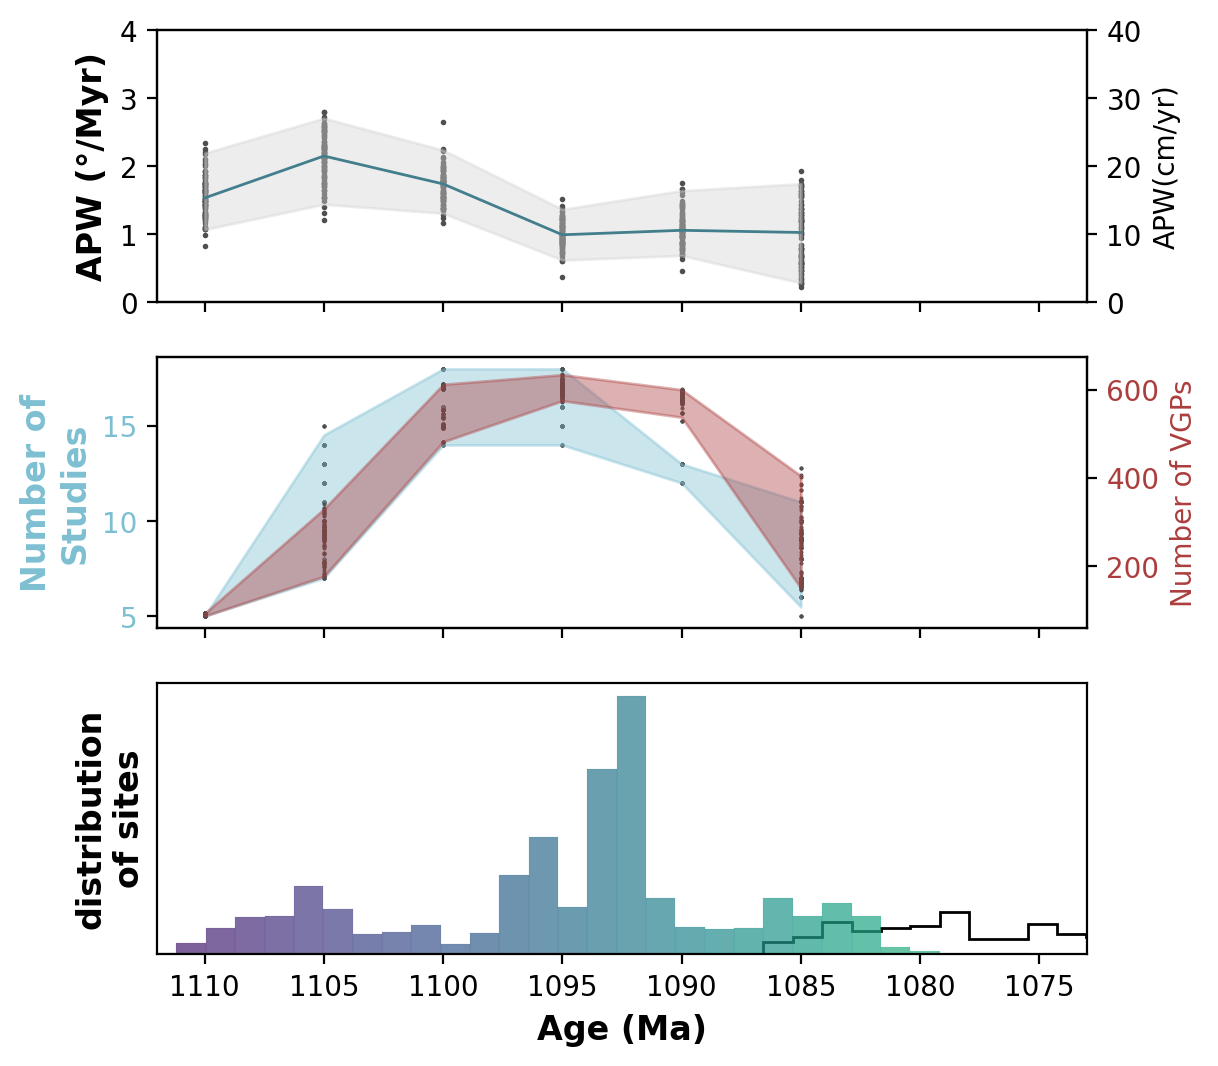

In [132]:
fig, axes = plt.subplots(3, 1, figsize=(6,6), sharex=True)

# Set Axis Labels
axes[0].set_ylabel(r'APW (°/Myr)', fontweight ='bold', fontsize = 12)
axes[1].set_ylabel('Number of\nStudies', fontweight ='bold', fontsize = 12, color="#7DBFD2")
axes[2].set_ylabel('distribution\nof sites', fontweight ='bold', fontsize = 12)
axes[2].set_yticks([])
axes[2].set_xlabel(r'Age (Ma)', fontweight ='bold', fontsize = 12)


# red = ##7F4141
for run, df_run in ultimate_ensemble_rates.groupby('effective_age'):
    axes[0].scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.APW_rate.to_numpy()[df_run.effective_age.to_numpy() >2], color="#4F4F4F", zorder =0, s=1)
axes[0].fill_between(np.sort(ensemble_apw_ef_.X), ensemble_apw_ef_.q025, ensemble_apw_ef_.q975, color= "lightgrey", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
axes[0].plot(np.sort(ensemble_apw_ef_.X), ensemble_apw_ef_.q50,color="#427E8C", zorder =3, linewidth=1, label="Ensemble Median")
axes[0].set_ylim(0, 4.0)
axes[0].set_yticks([0, 1, 2, 3, 4])
ax1 = axes[0].twinx()
ax1.set_yticks([0, 1, 2, 3, 4], [0, 10, 20, 30, 40])
ax1.set_ylabel('APW(cm/yr)', color="k")

for run, df_run in ultimate_ensemble_rates.groupby('effective_age'):
    if run == 1080:
        continue
    else:
        axes[1].scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.n_studies.to_numpy()[df_run.effective_age.to_numpy() > 2], color="#4F4F4F",  zorder =0, s=0.2)
axes[1].fill_between(np.sort(ensemble_n_studies.X)[1:], ensemble_n_studies.q025[1:],ensemble_n_studies.q975[1:], color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
axes[1].tick_params(axis='y', labelcolor="#7DBFD2")

ax2 = axes[1].twinx()  # instantiate a second axes that shares the same x-axis

for run, df_run in ultimate_ensemble_rates.groupby('effective_age'):
    if run == 1080:
        continue
    else:
        ax2.scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.N.to_numpy()[df_run.effective_age.to_numpy() > 2], color="#4F4F4F",  zorder =0, s=0.2)
ax2.fill_between(np.sort(ensemble_n_vgps.X[1:]), ensemble_n_vgps.q025[1:], ensemble_n_vgps.q975[1:], color= "#ac3d3d", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
ax2.set_ylabel('Number of VGPs', color="#ac3d3d")
ax2.tick_params(axis='y', labelcolor="#ac3d3d")
ax2.grid(False)

# Histogram 1

hist, bin_edges = np.histogram(pseudo_ultimate_sites_ensemble_w_MAD_no_Oronto['age'], bins=all_data_bins)
# Compute bin centers for coloring
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# Create a colormap based on the x-axis values (bin centers)
norm = Normalize(vmin=1060, vmax=1115)
cmap = plt.cm.viridis_r

# Plot the histogram
for i in range(len(all_data_bins) - 1):
    axes[2].bar(bin_edges[i], hist[i], width=bin_edges[i+1] - bin_edges[i],
           color=cmap(norm(bin_centers[i])), align='edge', alpha=0.7, edgecolor=colorConverter.to_rgba(cmap(norm(bin_centers[i])), alpha=.0), lw=0.05)
    
resampled_Oronto.hist(
    bins=all_data_bins,
    color='skyblue',
    edgecolor=None,
    ax=axes[2],
    histtype='step',
    zorder=0
)
axes[2].grid(False)

axes[0].set_xlim(1112, 1073)
axes[1].set_xlim(1112, 1073)
axes[2].set_xlim(1112, 1073)

plt.savefig('../figure/Keweenawan_ultimate_ensemble_stats_no_Oronto.pdf', bbox_inches='tight')

### 6. resample the Keweenawan_track_site_data_wo_MAD_conversion

In [35]:
df_ultimate_RM_ensemble_wo_MAD, pseudo_ultimate_sites_ensemble_wo_MAD = ultimate_ensemble_RMs_parallel(Keweenawan_track_site_data_wo_MAD_conversion, age_model_posterior_df, seds_f_df, n_sims = n_sims, min_age=1075)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 out of  50 | elapsed:    3.1s remaining:    1.5s
[Parallel(n_jobs=-1)]: Done  45 out of  50 | elapsed:    3.7s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    4.0s finished


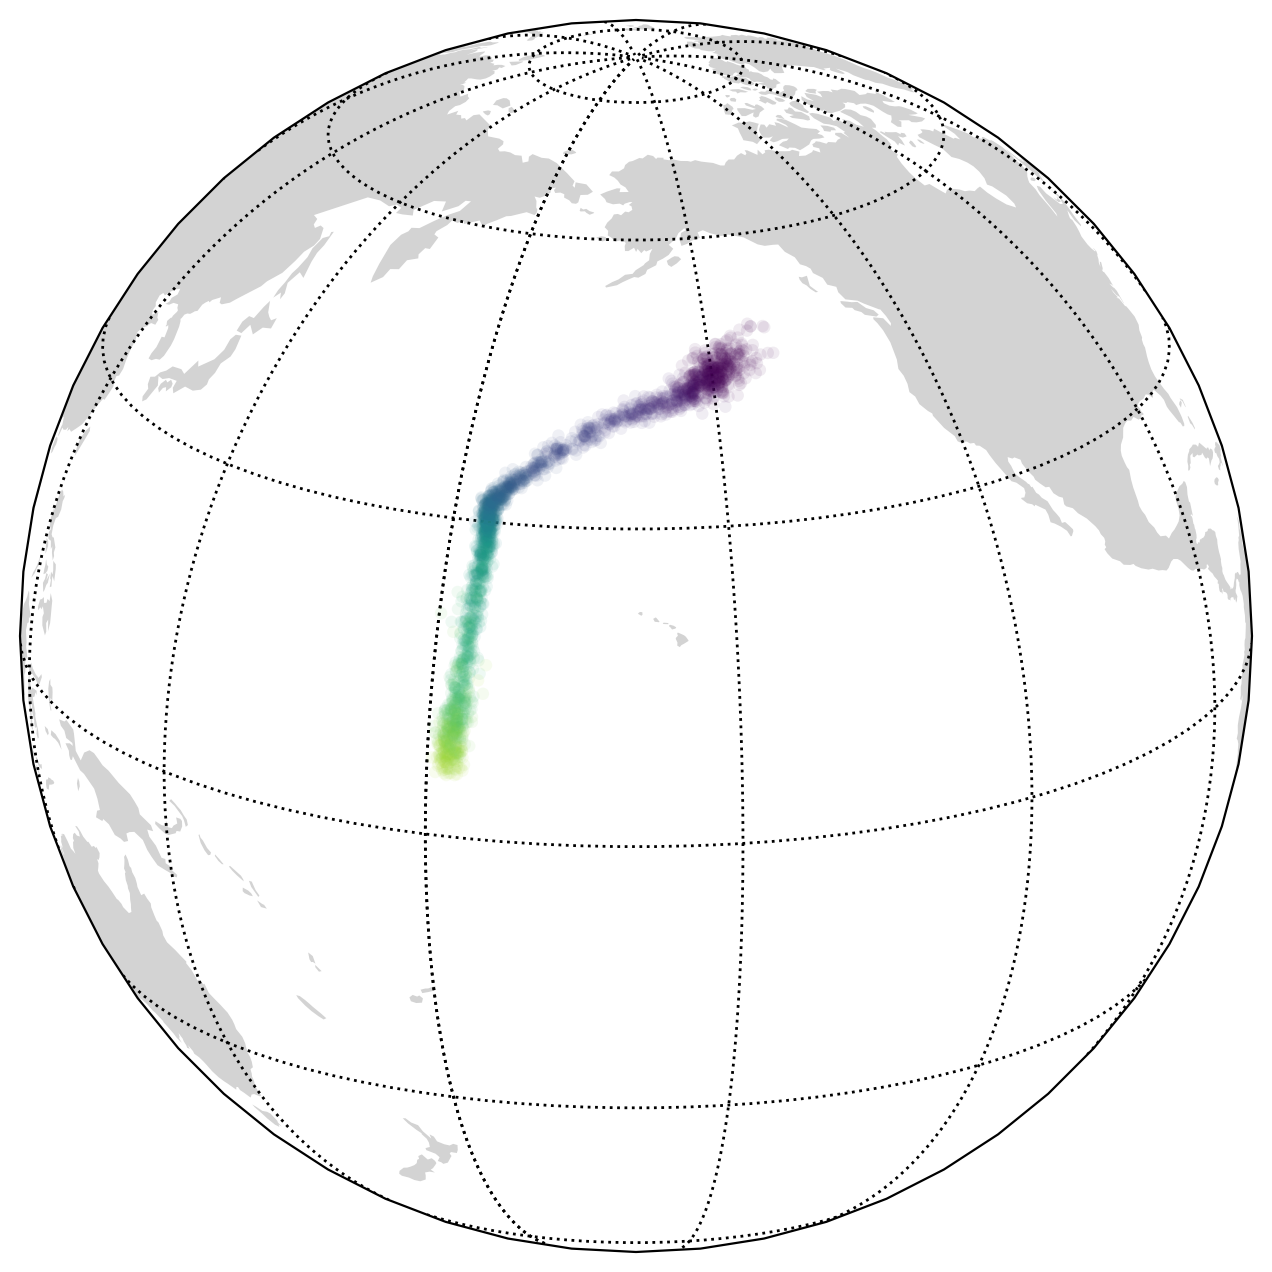

In [36]:
ax = ipmag.make_orthographic_map(200, 20, land_edge_color='none', land_color='lightgrey')
ipmag.plot_poles_colorbar(ax, df_ultimate_RM_ensemble_wo_MAD['plon'], df_ultimate_RM_ensemble_wo_MAD['plat'], 
                          np.zeros(df_ultimate_RM_ensemble_wo_MAD.shape[0]), marker='o', 
                          colorvalues=df_ultimate_RM_ensemble_wo_MAD['age'], vmin=1070, vmax=1110, 
                          colormap='viridis_r',
                          alpha=0.08, edgecolor='none', colorbar=0)
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_VGPs.png', dpi=300, bbox_inches='tight')

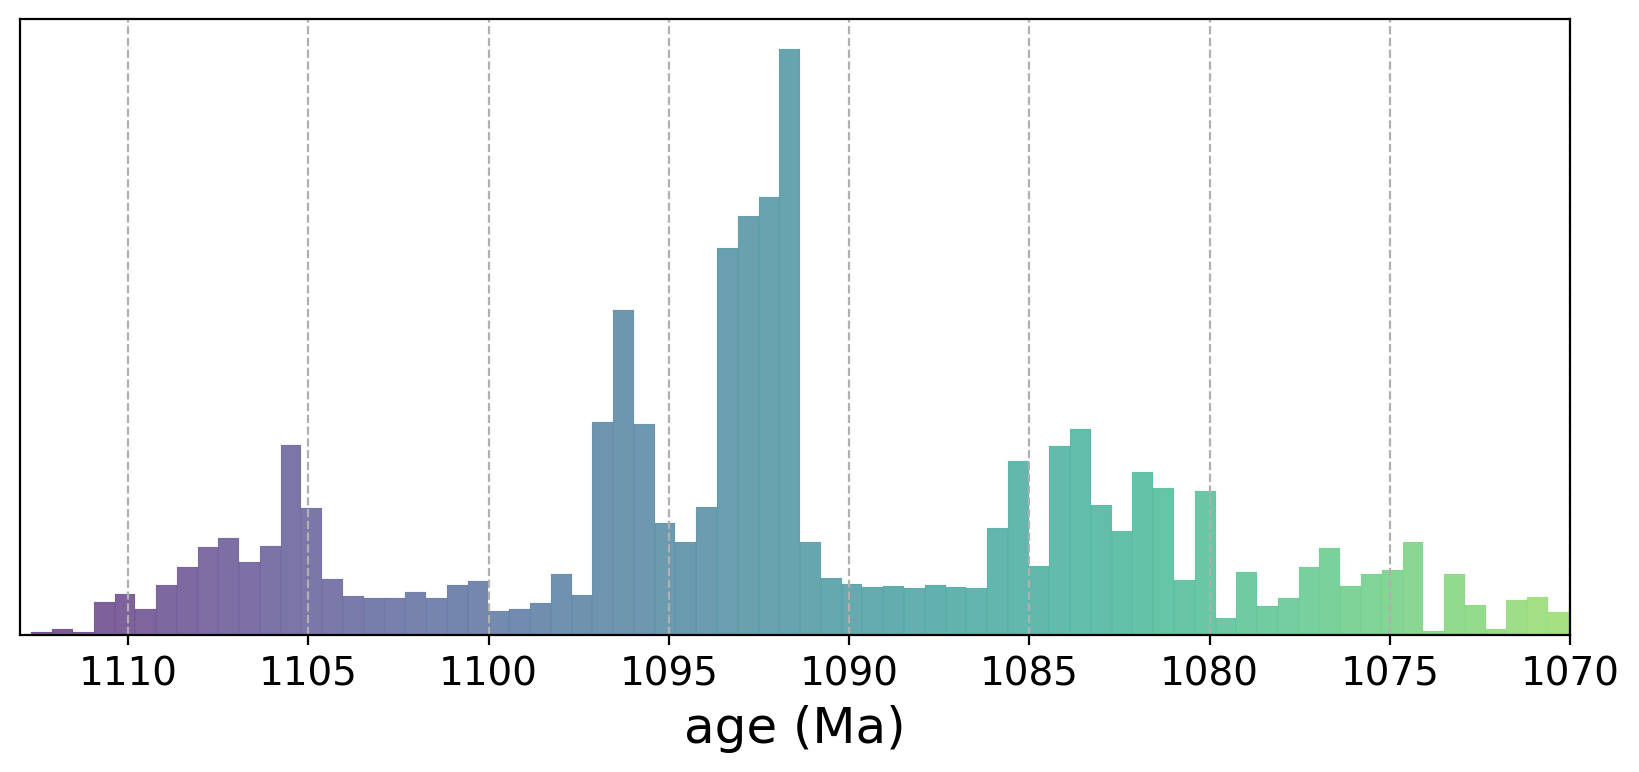

In [37]:
bins = 100
hist, bin_edges = np.histogram(pseudo_ultimate_sites_ensemble_wo_MAD['age'], bins)
# Compute bin centers for coloring
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# Create a colormap based on the x-axis values (bin centers)
norm = Normalize(vmin=1060, vmax=1115)
cmap = plt.cm.viridis_r

# Plot the histogram
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(bins):
    ax.bar(bin_edges[i], hist[i], width=bin_edges[1]-bin_edges[0],
           color=cmap(norm(bin_centers[i])), align='edge', alpha=0.7, edgecolor=colorConverter.to_rgba(cmap(norm(bin_centers[i])), alpha=.0), lw=0.05)
    
plt.gca().invert_xaxis()
plt.grid(True, ls='--')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_visible(False)
ax.set_yticks([])
plt.xlim(1113, 1070)
plt.xticks(fontsize=14)
ax.set_xlabel('age (Ma)', fontsize=18)
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_site_age_hist.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [38]:
df_ultimate_RM_ensemble_wo_MAD

,age,N,n_studies,k,A95,csd,plon,plat,foliation,lineation,...,elong_dir,effective_age,effective_age_std,effective_age_median,distance2age,GCD,APW_rate,APW_rate_eff_age,angle,run
0,1075.0,274.0,6.0,25.589932,1.713214,16.012180,180.511407,7.490364,0.398112,3.033337,...,-100.637407,1083.0,1.299739,1083.0,7.0,NaN,NaN,NaN,NaN,0.0
1,1076.0,324.0,8.0,24.670718,1.605109,16.307753,182.132446,8.761873,0.262573,3.048887,...,85.619601,1083.0,1.111982,1083.0,7.0,2.047408,2.047408,NaN,137.076667,0.0
2,1077.0,337.0,7.0,24.467688,1.580499,16.375273,182.317800,9.940886,0.212169,3.066790,...,-126.863082,1083.0,1.333738,1083.0,6.0,1.193114,1.193114,NaN,69.335846,0.0
3,1078.0,352.0,8.0,23.023714,1.596195,16.880967,181.097993,9.686810,0.219225,2.993091,...,-109.761559,1083.0,1.300836,1083.0,3.0,1.228517,1.228517,NaN,15.387138,0.0
4,1079.0,359.0,7.0,22.998112,1.581411,16.890361,182.881496,10.591865,0.249828,2.982822,...,-123.403820,1083.0,1.479948,1083.0,2.0,1.975184,1.975184,NaN,12.982776,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2045,1111.0,161.0,7.0,23.632408,2.334088,16.662150,207.657535,46.648205,0.595017,2.870898,...,131.991408,1107.0,2.341474,1107.0,-3.0,1.506446,1.506446,1.506446,108.122951,49.0
2046,1112.0,153.0,7.0,19.219819,2.669169,18.476103,211.795976,47.099652,0.453487,2.702490,...,139.891452,1108.0,2.330050,1108.0,-4.0,2.864501,2.864501,2.864501,162.476161,49.0
2047,1113.0,148.0,7.0,22.065750,2.524362,17.243510,213.058003,46.941219,0.263020,2.929298,...,-37.772657,1107.0,2.152761,1108.0,-6.0,0.874826,0.874826,-0.874826,57.715021,49.0
2048,1114.0,125.0,6.0,21.666611,2.775788,17.401614,212.917261,46.838538,0.425680,2.841256,...,144.815816,1108.0,1.992081,1108.0,-7.0,0.140693,0.140693,0.140693,66.830884,49.0


In [39]:
ultimate_ensemble_rates = pd.DataFrame()
for j in range(n_sims):
    df = pd.DataFrame()
    for i in np.sort(df_ultimate_RM_ensemble_wo_MAD['effective_age'].unique())[::4]:
        pole = df_ultimate_RM_ensemble_wo_MAD[df_ultimate_RM_ensemble_wo_MAD['effective_age'] == i].sample(n=1)
        df = pd.concat([df, pole], ignore_index=True)
    # The following block calculates rate of polar wander (degrees per million years) 
    df['run'] = j
    df['PPcartesian'] = df.apply(lambda row: spherical2cartesian([np.radians(row['plat']),np.radians(row['plon'])]), axis = 1)
    df['PP_prev'] = df['PPcartesian'].shift(periods = 1)
    df['PP_next'] =  df['PPcartesian'].shift(periods = -1)
    df['GCD'] = df.apply(lambda row: np.degrees(GCD_cartesian(row['PP_prev'], row['PPcartesian'])), axis = 1)
    df['APW_rate'] = df['GCD']/df['effective_age'].diff()
    ultimate_ensemble_rates = pd.concat([ultimate_ensemble_rates, df], ignore_index=True)

# Set the level confidence at which we want to work 
quantile = 95

# Since the Latitude and Longitude covaries, we need to calculate the Principal component for each timre-dependant point Cloud 
# the class PC() has also methods to aid in the calculatrio
ensemble_PC_eff_age = PC(df_ultimate_RM_ensemble_wo_MAD,"effective_age","plat","plon") # set principal component for each Age

# # Ensemble's parameters (e.g. Apparent polar wander rate, age difference)
ensemble_apw_eff = quantiles(df_ultimate_RM_ensemble_wo_MAD,"effective_age","APW_rate") # set quantiles of latitude groupedby age for visualization purposes
ensemble_apw_ef_ = quantiles(ultimate_ensemble_rates,"effective_age","APW_rate") # set quantiles of latitude groupedby age for visualization purposes

ensemble_n_studies = quantiles(ultimate_ensemble_rates,"effective_age","n_studies")
ensemble_n_vgps = quantiles(ultimate_ensemble_rates,"effective_age","N")

#### calcualte average APWP rates

(1110.0, 1070.0)

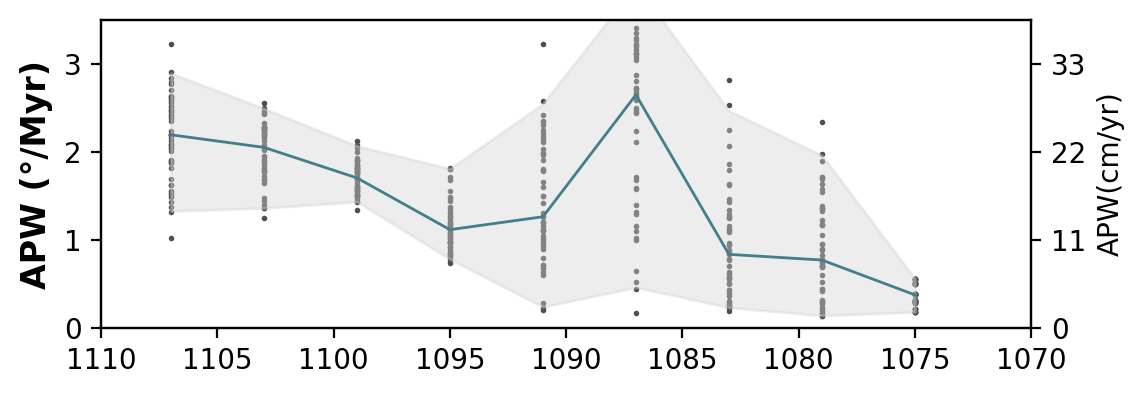

In [40]:
fig, axes = plt.subplots(1, 1, figsize=(6,2), sharex=True)

# Set Axis Labels
axes.set_ylabel(r'APW (°/Myr)', fontweight ='bold', fontsize = 12)

# plot 50 runs to save computational cost and very dense graphics 
df_RM_ensemble_50 = df_ultimate_RM_ensemble_wo_MAD[df_ultimate_RM_ensemble_wo_MAD['run'].isin(range(0,100))]
# red = ##7F4141
for run, df_run in ultimate_ensemble_rates.groupby('run'):
    axes.scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() >= 2], df_run.APW_rate.to_numpy()[df_run.effective_age.to_numpy() >=2], color="#4F4F4F", zorder =0, s=1)
axes.fill_between(np.sort(ensemble_apw_ef_.X), ensemble_apw_ef_.q025, ensemble_apw_ef_.q975, color= "lightgrey", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
axes.plot(np.sort(ensemble_apw_ef_.X), ensemble_apw_ef_.q50,color="#427E8C", zorder =3, linewidth=1, label="Ensemble Median")
axes.set_ylim(0, 3.5)
axes.set_yticks([0, 1, 2, 3])
ax1 = axes.twinx()
ax1.set_ylim(0, 3.5)
ax1.set_yticks([0, 1, 2, 3], [0, 11, 22, 33])
ax1.set_ylabel('APW(cm/yr)', color="k")

axes.set_xlim(1110, 1070)
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_stats_APW_rate.pdf', bbox_inches='tight')


(1112.0, 1070.0)

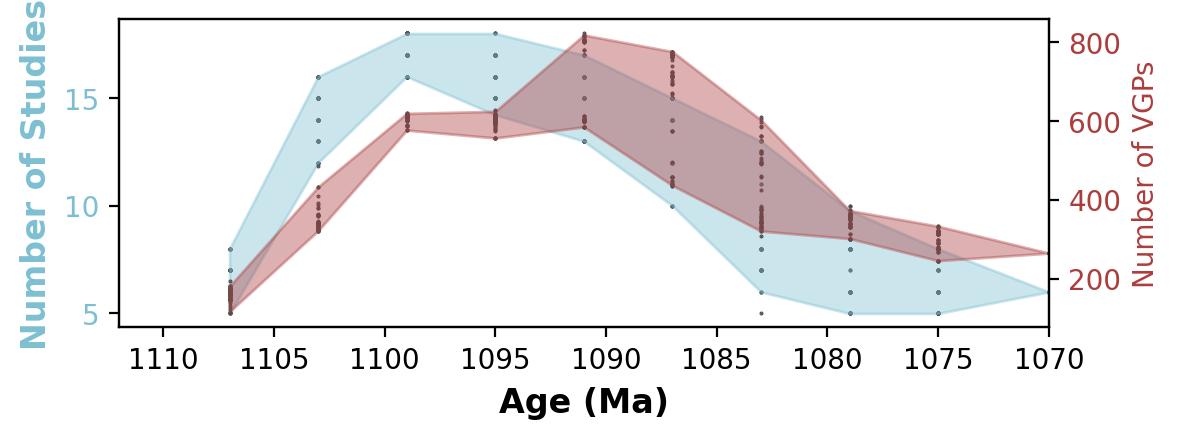

In [41]:
fig, axes = plt.subplots(1, 1, figsize=(6,2), sharex=True)

# Set Axis Labels
axes.set_ylabel(r'Number of Studies', fontweight ='bold', fontsize = 12, color="#7DBFD2")
axes.set_xlabel(r'Age (Ma)', fontweight ='bold', fontsize = 12)


for run, df_run in ultimate_ensemble_rates.groupby('run'):
    axes.scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.n_studies.to_numpy()[df_run.effective_age.to_numpy() > 2], color="#4F4F4F",  zorder =0, s=0.2)
axes.fill_between(np.sort(ensemble_n_studies.X), ensemble_n_studies.q025,ensemble_n_studies.q975, color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
axes.tick_params(axis='y', labelcolor="#7DBFD2")
ax2 = axes.twinx()  # instantiate a second axes that shares the same x-axis

for run, df_run in ultimate_ensemble_rates.groupby('run'):
    ax2.scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.N.to_numpy()[df_run.effective_age.to_numpy() > 2], color="#4F4F4F",  zorder =0, s=0.2)
ax2.fill_between(np.sort(ensemble_n_vgps.X), ensemble_n_vgps.q025,ensemble_n_vgps.q975, color= "#ac3d3d", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
ax2.set_ylabel('Number of VGPs', color="#ac3d3d")
ax2.tick_params(axis='y', labelcolor="#ac3d3d")
ax2.grid(False)
axes.set_xlim(1112, 1070)


# plt.gca().invert_xaxis()
# axes[0].legend(loc="upper left")
# axes[2].legend(loc="upper left")
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_stats_n.pdf', bbox_inches='tight')


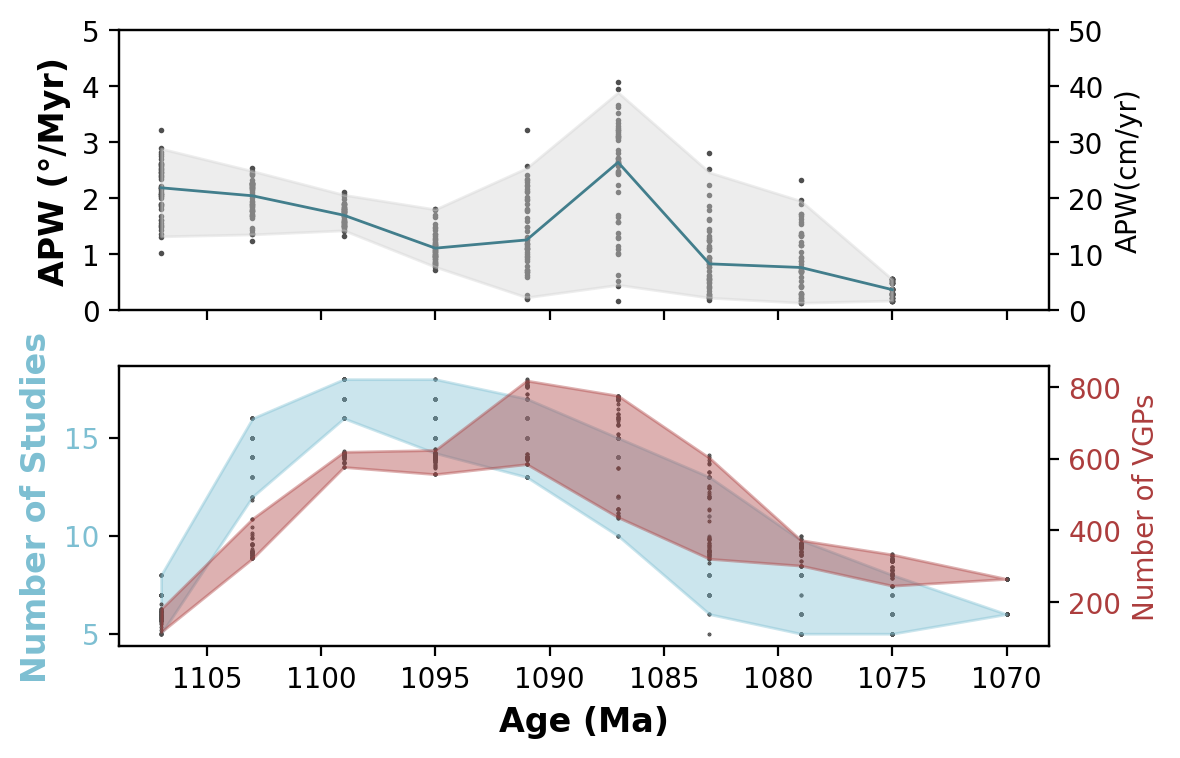

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(6,4), sharex=True)

# Set Axis Labels
axes[0].set_ylabel(r'APW (°/Myr)', fontweight ='bold', fontsize = 12)
axes[1].set_ylabel(r'Number of Studies', fontweight ='bold', fontsize = 12, color="#7DBFD2")
axes[1].set_xlabel(r'Age (Ma)', fontweight ='bold', fontsize = 12)

# plot 50 runs to save computational cost and very dense graphics 
df_RM_ensemble_50 = df_ultimate_RM_ensemble_wo_MAD[df_ultimate_RM_ensemble_wo_MAD['run'].isin(range(0,100))]
# red = ##7F4141
for run, df_run in ultimate_ensemble_rates.groupby('run'):
    axes[0].scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() >= 2], df_run.APW_rate.to_numpy()[df_run.effective_age.to_numpy() >=2], color="#4F4F4F", zorder =0, s=1)
axes[0].fill_between(np.sort(ensemble_apw_ef_.X), ensemble_apw_ef_.q025, ensemble_apw_ef_.q975, color= "lightgrey", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
axes[0].plot(np.sort(ensemble_apw_ef_.X), ensemble_apw_ef_.q50,color="#427E8C", zorder =3, linewidth=1, label="Ensemble Median")
axes[0].set_ylim(0, 5.0)
axes[0].set_yticks([0, 1, 2, 3, 4, 5])
ax1 = axes[0].twinx()
ax1.set_yticks([0, 1, 2, 3, 4, 5], [0, 10, 20, 30, 40, 50])
ax1.set_ylabel('APW(cm/yr)', color="k")

for run, df_run in ultimate_ensemble_rates.groupby('run'):
    axes[1].scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.n_studies.to_numpy()[df_run.effective_age.to_numpy() > 2], color="#4F4F4F",  zorder =0, s=0.2)
axes[1].fill_between(np.sort(ensemble_n_studies.X), ensemble_n_studies.q025,ensemble_n_studies.q975, color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
axes[1].tick_params(axis='y', labelcolor="#7DBFD2")
ax2 = axes[1].twinx()  # instantiate a second axes that shares the same x-axis

for run, df_run in ultimate_ensemble_rates.groupby('run'):
    ax2.scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.N.to_numpy()[df_run.effective_age.to_numpy() > 2], color="#4F4F4F",  zorder =0, s=0.2)
ax2.fill_between(np.sort(ensemble_n_vgps.X), ensemble_n_vgps.q025,ensemble_n_vgps.q975, color= "#ac3d3d", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
ax2.set_ylabel('Number of VGPs', color="#ac3d3d")
ax2.tick_params(axis='y', labelcolor="#ac3d3d")
ax2.grid(False)


plt.gca().invert_xaxis()
# axes[0].legend(loc="upper left")
# axes[2].legend(loc="upper left")
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_stats.pdf', bbox_inches='tight')


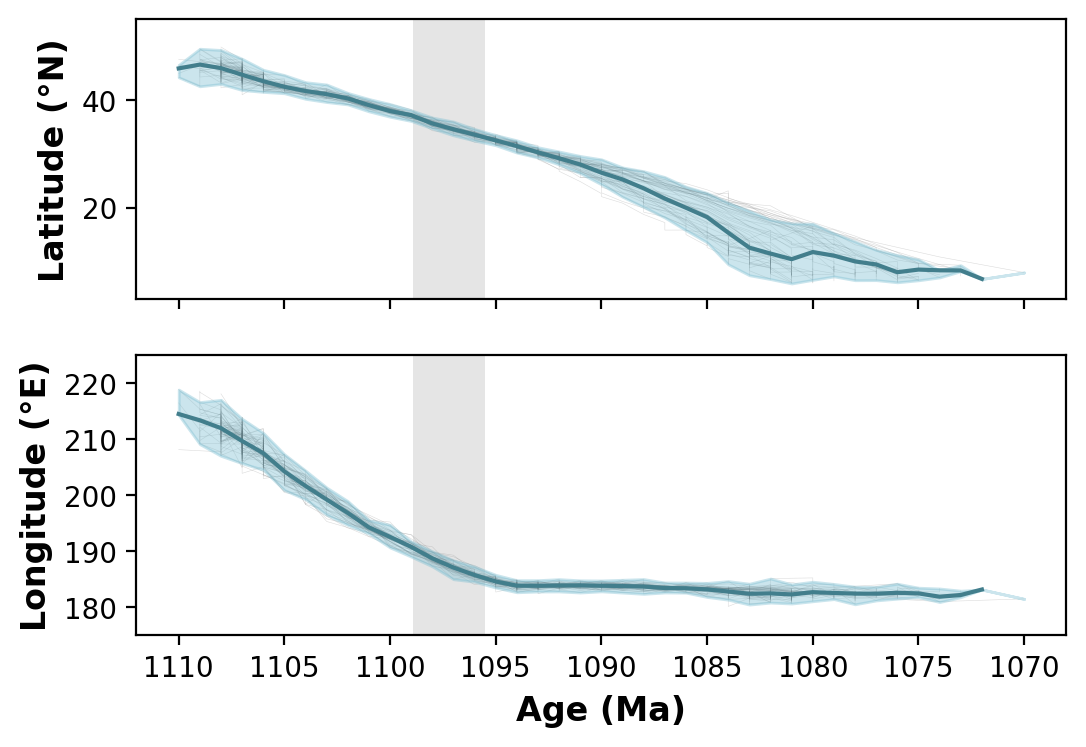

In [43]:
fig, axes = plt.subplots(2, 1, figsize=(6,4), sharex=True)

# Set Axis Labels
axes[0].set_ylabel(r'Latitude (°N)', fontweight ='bold', fontsize = 12)
axes[1].set_ylabel(r'Longitude (°E)', fontweight ='bold', fontsize = 12)
axes[1].set_xlabel(r'Age (Ma)', fontweight ='bold', fontsize = 12)

# LATITUDES 
for run, df_run in df_RM_ensemble_50.groupby('run'):
    axes[0].plot(df_run.effective_age.tolist(), df_run.plat.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, alpha=0.2)

# axes[0].plot(df_run.effective_age.tolist(), df_run.plat.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, label = 'Moving Average realization')
axes[0].fill_between(ensemble_PC_eff_age.X, ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[2], 
                     ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[3], 
                     color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
# axes[0].scatter(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[1],color="#314B54", s = 15,  label = 'Principal component of the age ensemble')  
axes[0].plot(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[1],color="#427E8C")  

# LONGITUDES     
for run, df_run in df_RM_ensemble_50.groupby('run'):
    axes[1].plot(df_run.effective_age.tolist(), df_run.plon.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, alpha=0.2)
# axes[1].plot(df_run.effective_age.tolist(), df_run.plon.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, label = 'Moving Average realization')
axes[1].fill_between(ensemble_PC_eff_age.X, ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[0], 
                     ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[1], 
                     color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
# axes[1].scatter(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[0]%360,color="#314B54", s = 15,  label = 'Principal component of the age ensemble')
axes[1].plot(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[0]%360,color="#427E8C")  

axes[0].fill_between([1095.5, 1098.9], [3,3], [55, 55], color='grey', lw=0, alpha=0.2, zorder=0)
axes[0].set_ylim(3, 55)

axes[1].fill_between([1095.5, 1098.9], [175,175], [225, 225], color='grey', lw=0, alpha=0.2, zorder=0)
axes[1].set_ylim(175, 225)
plt.gca().invert_xaxis()
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_APW_components.pdf', bbox_inches='tight')


### 7. resample the Keweenawan_track_site_data_w_MAD_filter

In [44]:
df_ultimate_RM_ensemble_w_MAD_filter, pseudo_ultimate_sites_ensemble_w_MAD_filter = ultimate_ensemble_RMs_parallel(Keweenawan_track_site_data_w_MAD_filter, age_model_posterior_df, seds_f_df, n_sims = n_sims, min_age=1075)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 out of  50 | elapsed:    2.6s remaining:    1.2s
[Parallel(n_jobs=-1)]: Done  45 out of  50 | elapsed:    3.2s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    3.5s finished


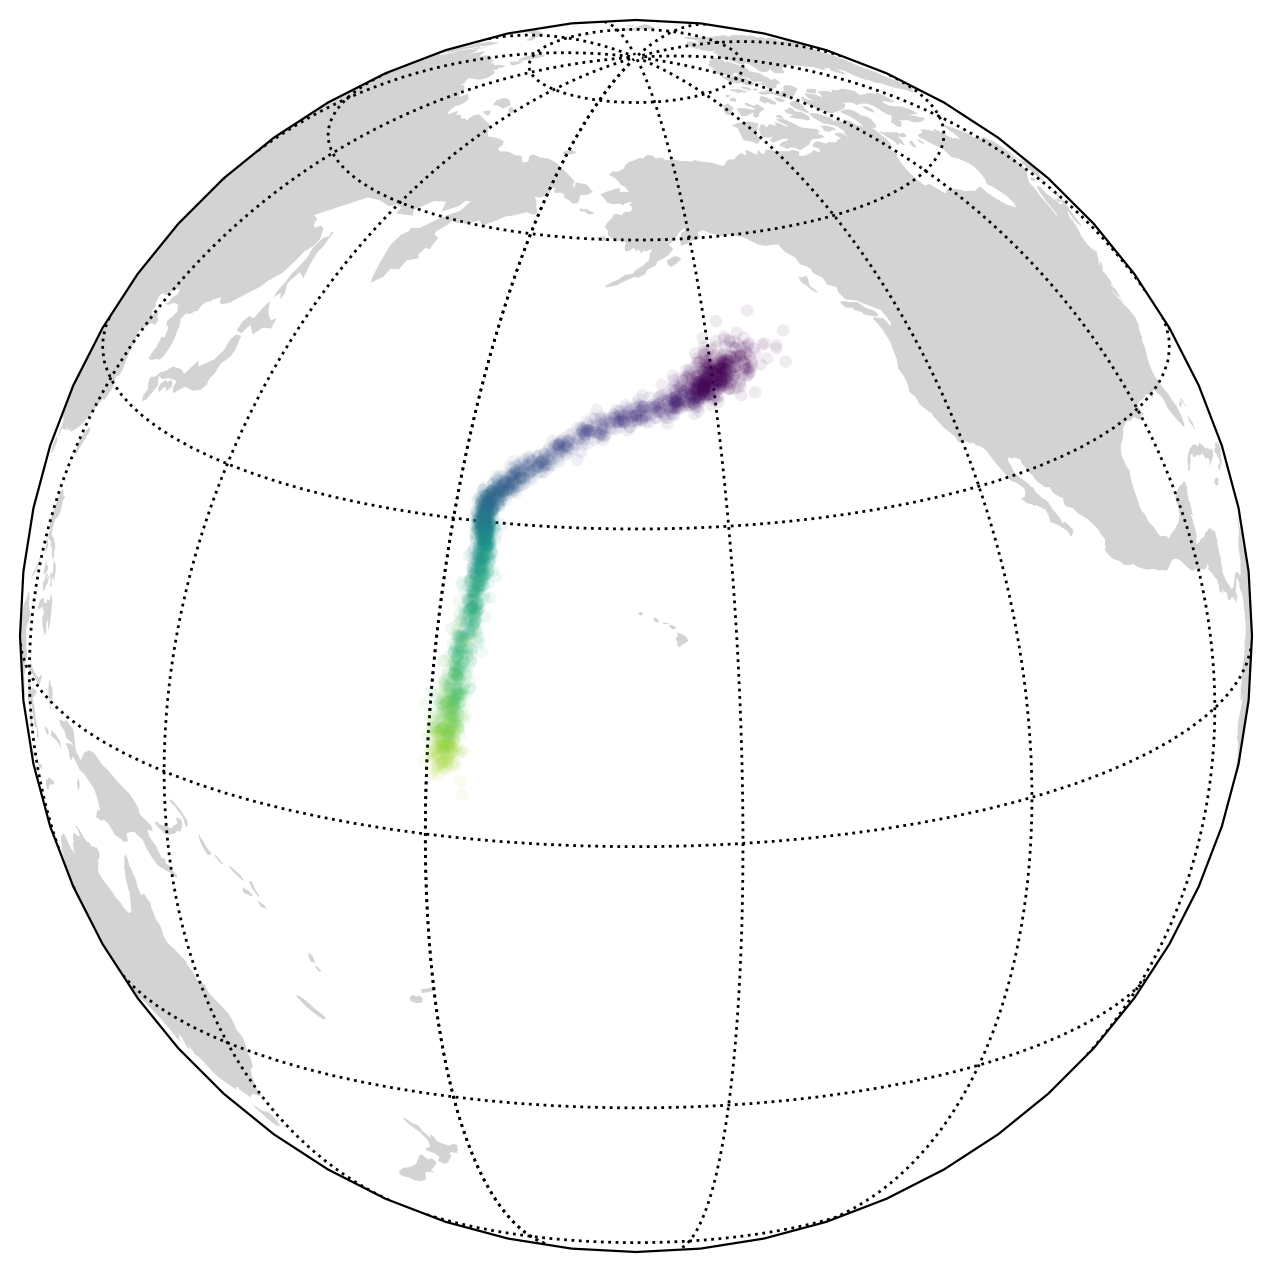

In [45]:
ax = ipmag.make_orthographic_map(200, 20, land_edge_color='none', land_color='lightgrey')
ipmag.plot_poles_colorbar(ax, df_ultimate_RM_ensemble_w_MAD_filter['plon'], df_ultimate_RM_ensemble_w_MAD_filter['plat'], 
                          np.zeros(df_ultimate_RM_ensemble_w_MAD_filter.shape[0]), marker='o', 
                          colorvalues=df_ultimate_RM_ensemble_w_MAD_filter['age'], vmin=1070, vmax=1110, 
                          colormap='viridis_r',
                          alpha=0.08, edgecolor='none', colorbar=0)
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_VGPs.png', dpi=300, bbox_inches='tight')

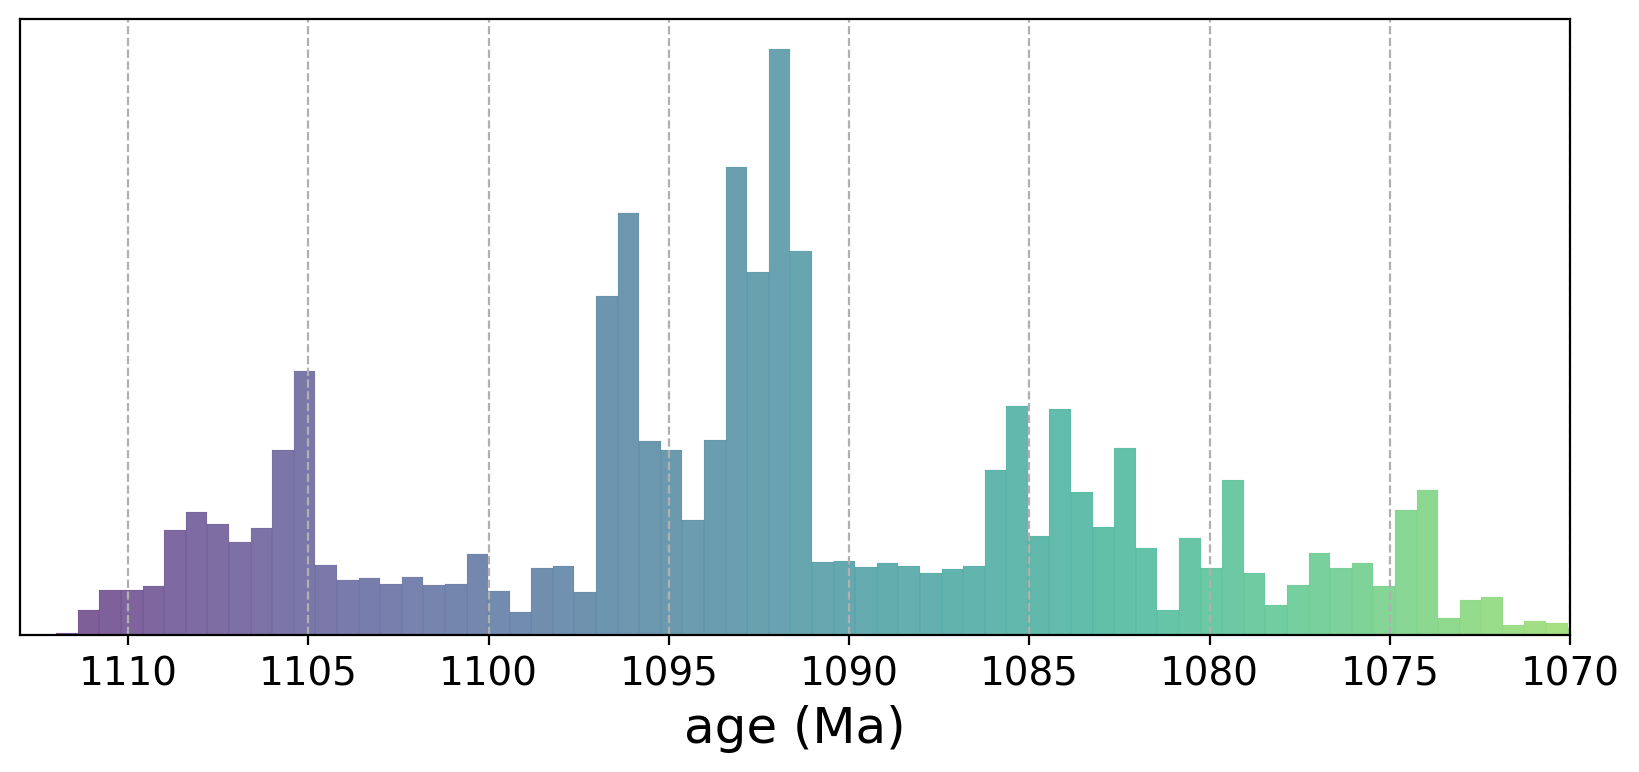

In [46]:
bins = 100
hist, bin_edges = np.histogram(pseudo_ultimate_sites_ensemble_w_MAD_filter['age'], bins)
# Compute bin centers for coloring
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# Create a colormap based on the x-axis values (bin centers)
norm = Normalize(vmin=1060, vmax=1115)
cmap = plt.cm.viridis_r

# Plot the histogram
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(bins):
    ax.bar(bin_edges[i], hist[i], width=bin_edges[1]-bin_edges[0],
           color=cmap(norm(bin_centers[i])), align='edge', alpha=0.7, edgecolor=colorConverter.to_rgba(cmap(norm(bin_centers[i])), alpha=.0), lw=0.05)
    
plt.gca().invert_xaxis()
plt.grid(True, ls='--')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_visible(False)
ax.set_yticks([])
plt.xlim(1113, 1070)
plt.xticks(fontsize=14)
ax.set_xlabel('age (Ma)', fontsize=18)
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_site_age_hist.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [47]:
df_ultimate_RM_ensemble_w_MAD_filter

,age,N,n_studies,k,A95,csd,plon,plat,foliation,lineation,...,elong_dir,effective_age,effective_age_std,effective_age_median,distance2age,GCD,APW_rate,APW_rate_eff_age,angle,run
0,1075.0,227.0,5.0,25.824927,1.874364,15.939161,180.502748,7.257156,0.725133,2.926373,...,-95.391014,1075.0,2.375432,1074.0,1.0,NaN,NaN,NaN,NaN,0.0
1,1076.0,267.0,6.0,24.133612,1.789444,16.488223,181.705164,6.631830,0.498052,2.926953,...,87.023561,1075.0,3.163975,1074.0,-3.0,1.347473,1.347473,NaN,107.604628,0.0
2,1077.0,277.0,6.0,25.058964,1.722559,16.180929,183.507082,8.391010,0.398294,3.014398,...,83.341951,1076.0,3.962229,1074.0,-7.0,2.507164,2.507164,2.507164,107.581405,0.0
3,1078.0,284.0,8.0,22.437942,1.802067,17.099898,181.710273,11.861148,0.395090,2.897826,...,-103.655707,1077.0,4.486664,1074.0,0.0,3.894808,3.894808,3.894808,176.060311,0.0
4,1079.0,282.0,8.0,23.081891,1.781918,16.859680,180.709269,13.472466,0.179175,3.025578,...,-20.178046,1079.0,4.909824,1074.0,-2.0,1.884171,1.884171,0.942086,129.210517,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2045,1111.0,162.0,7.0,18.270141,2.663597,18.950212,210.251302,45.218923,0.314788,2.700148,...,133.472771,1107.0,1.680091,1107.0,-5.0,2.621153,2.621153,NaN,45.664757,49.0
2046,1112.0,160.0,7.0,22.736812,2.389181,16.987139,210.393480,42.055711,0.352251,2.924227,...,136.912115,1107.0,1.562853,1107.0,-7.0,3.164884,3.164884,NaN,15.184271,49.0
2047,1113.0,142.0,6.0,19.586631,2.744194,18.302278,211.343758,44.885738,0.433774,2.730154,...,129.235796,1107.0,1.463333,1107.0,-6.0,2.912782,2.912782,NaN,112.842124,49.0
2048,1114.0,137.0,6.0,22.666110,2.588202,17.013612,215.032711,45.229498,0.163593,3.000973,...,-152.229059,1107.0,1.414041,1108.0,-6.0,2.628196,2.628196,NaN,58.879531,49.0


In [48]:
ultimate_ensemble_rates = pd.DataFrame()
for j in range(n_sims):
    df = pd.DataFrame()
    for i in np.sort(df_ultimate_RM_ensemble_w_MAD_filter['effective_age'].unique())[::4]:
        pole = df_ultimate_RM_ensemble_w_MAD_filter[df_ultimate_RM_ensemble_w_MAD_filter['effective_age'] == i].sample(n=1)
        df = pd.concat([df, pole], ignore_index=True)
    # The following block calculates rate of polar wander (degrees per million years) 
    df['run'] = j
    df['PPcartesian'] = df.apply(lambda row: spherical2cartesian([np.radians(row['plat']),np.radians(row['plon'])]), axis = 1)
    df['PP_prev'] = df['PPcartesian'].shift(periods = 1)
    df['PP_next'] =  df['PPcartesian'].shift(periods = -1)
    df['GCD'] = df.apply(lambda row: np.degrees(GCD_cartesian(row['PP_prev'], row['PPcartesian'])), axis = 1)
    df['APW_rate'] = df['GCD']/df['effective_age'].diff()
    ultimate_ensemble_rates = pd.concat([ultimate_ensemble_rates, df], ignore_index=True)

# Set the level confidence at which we want to work 
quantile = 95

# Since the Latitude and Longitude covaries, we need to calculate the Principal component for each timre-dependant point Cloud 
# the class PC() has also methods to aid in the calculatrio
ensemble_PC_eff_age = PC(df_ultimate_RM_ensemble_w_MAD_filter,"effective_age","plat","plon") # set principal component for each Age

# # Ensemble's parameters (e.g. Apparent polar wander rate, age difference)
ensemble_apw_eff = quantiles(df_ultimate_RM_ensemble_w_MAD_filter,"effective_age","APW_rate") # set quantiles of latitude groupedby age for visualization purposes
ensemble_apw_ef_ = quantiles(ultimate_ensemble_rates,"effective_age","APW_rate") # set quantiles of latitude groupedby age for visualization purposes

ensemble_n_studies = quantiles(ultimate_ensemble_rates,"effective_age","n_studies")
ensemble_n_vgps = quantiles(ultimate_ensemble_rates,"effective_age","N")

#### calcualte average APWP rates

(1110.0, 1070.0)

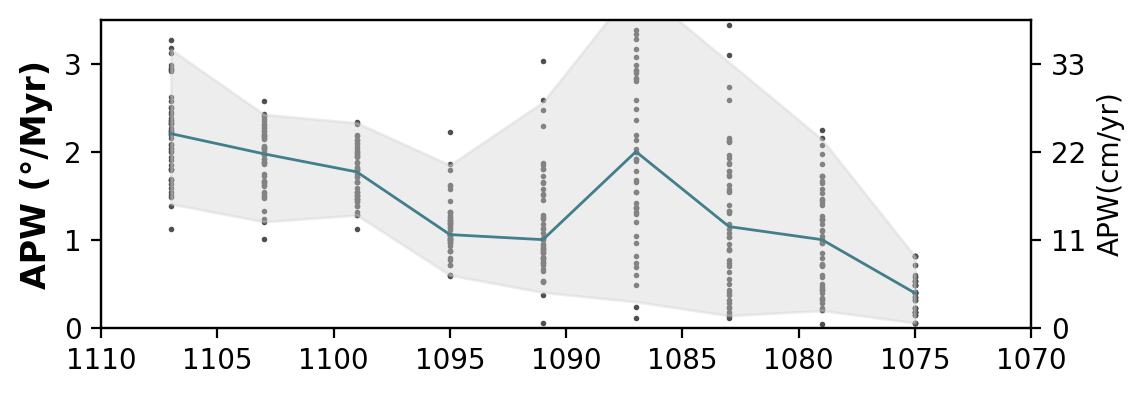

In [49]:
fig, axes = plt.subplots(1, 1, figsize=(6,2), sharex=True)

# Set Axis Labels
axes.set_ylabel(r'APW (°/Myr)', fontweight ='bold', fontsize = 12)

# plot 50 runs to save computational cost and very dense graphics 
df_RM_ensemble_50 = df_ultimate_RM_ensemble_w_MAD_filter[df_ultimate_RM_ensemble_w_MAD_filter['run'].isin(range(0,100))]
# red = ##7F4141
for run, df_run in ultimate_ensemble_rates.groupby('run'):
    axes.scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() >= 2], df_run.APW_rate.to_numpy()[df_run.effective_age.to_numpy() >=2], color="#4F4F4F", zorder =0, s=1)
axes.fill_between(np.sort(ensemble_apw_ef_.X), ensemble_apw_ef_.q025, ensemble_apw_ef_.q975, color= "lightgrey", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
axes.plot(np.sort(ensemble_apw_ef_.X), ensemble_apw_ef_.q50,color="#427E8C", zorder =3, linewidth=1, label="Ensemble Median")
axes.set_ylim(0, 3.5)
axes.set_yticks([0, 1, 2, 3])
ax1 = axes.twinx()
ax1.set_ylim(0, 3.5)
ax1.set_yticks([0, 1, 2, 3], [0, 11, 22, 33])
ax1.set_ylabel('APW(cm/yr)', color="k")

axes.set_xlim(1110, 1070)
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_stats_APW_rate.pdf', bbox_inches='tight')


(1112.0, 1077.0)

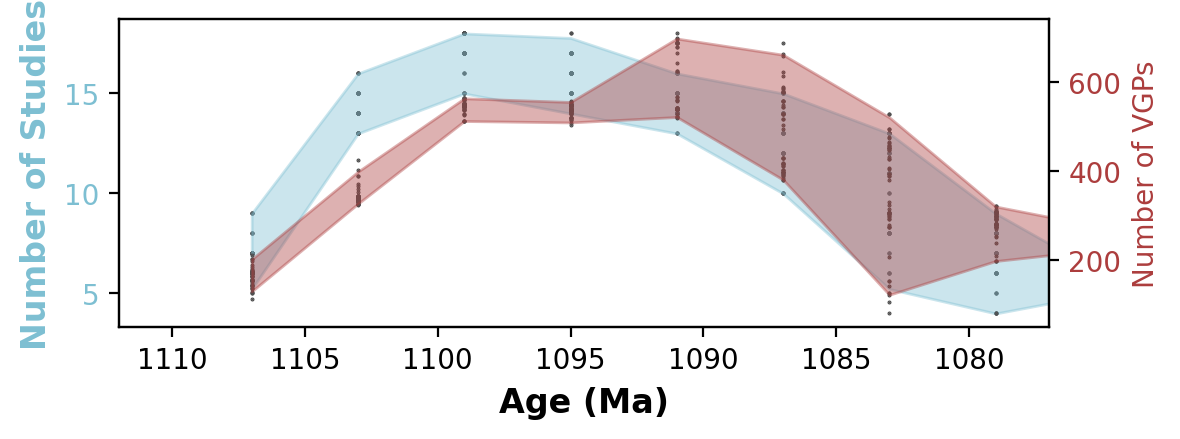

In [50]:
fig, axes = plt.subplots(1, 1, figsize=(6,2), sharex=True)

# Set Axis Labels
axes.set_ylabel(r'Number of Studies', fontweight ='bold', fontsize = 12, color="#7DBFD2")
axes.set_xlabel(r'Age (Ma)', fontweight ='bold', fontsize = 12)


for run, df_run in ultimate_ensemble_rates.groupby('run'):
    axes.scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.n_studies.to_numpy()[df_run.effective_age.to_numpy() > 2], color="#4F4F4F",  zorder =0, s=0.2)
axes.fill_between(np.sort(ensemble_n_studies.X), ensemble_n_studies.q025,ensemble_n_studies.q975, color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
axes.tick_params(axis='y', labelcolor="#7DBFD2")
ax2 = axes.twinx()  # instantiate a second axes that shares the same x-axis

for run, df_run in ultimate_ensemble_rates.groupby('run'):
    ax2.scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.N.to_numpy()[df_run.effective_age.to_numpy() > 2], color="#4F4F4F",  zorder =0, s=0.2)
ax2.fill_between(np.sort(ensemble_n_vgps.X), ensemble_n_vgps.q025,ensemble_n_vgps.q975, color= "#ac3d3d", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
ax2.set_ylabel('Number of VGPs', color="#ac3d3d")
ax2.tick_params(axis='y', labelcolor="#ac3d3d")
ax2.grid(False)
axes.set_xlim(1112, 1077)


# plt.gca().invert_xaxis()
# axes[0].legend(loc="upper left")
# axes[2].legend(loc="upper left")
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_stats_n.pdf', bbox_inches='tight')


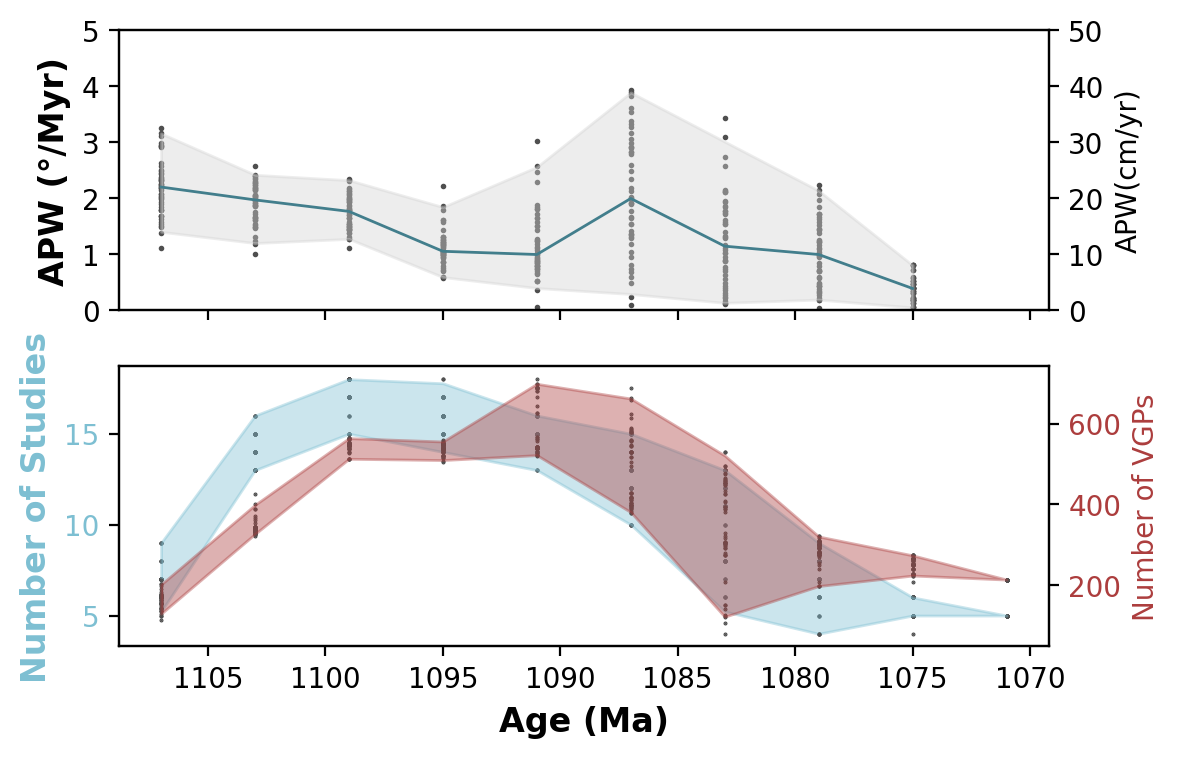

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(6,4), sharex=True)

# Set Axis Labels
axes[0].set_ylabel(r'APW (°/Myr)', fontweight ='bold', fontsize = 12)
axes[1].set_ylabel(r'Number of Studies', fontweight ='bold', fontsize = 12, color="#7DBFD2")
axes[1].set_xlabel(r'Age (Ma)', fontweight ='bold', fontsize = 12)

# plot 50 runs to save computational cost and very dense graphics 
df_RM_ensemble_50 = df_ultimate_RM_ensemble_w_MAD_filter[df_ultimate_RM_ensemble_w_MAD_filter['run'].isin(range(0,100))]
# red = ##7F4141
for run, df_run in ultimate_ensemble_rates.groupby('run'):
    axes[0].scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() >= 2], df_run.APW_rate.to_numpy()[df_run.effective_age.to_numpy() >=2], color="#4F4F4F", zorder =0, s=1)
axes[0].fill_between(np.sort(ensemble_apw_ef_.X), ensemble_apw_ef_.q025, ensemble_apw_ef_.q975, color= "lightgrey", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
axes[0].plot(np.sort(ensemble_apw_ef_.X), ensemble_apw_ef_.q50,color="#427E8C", zorder =3, linewidth=1, label="Ensemble Median")
axes[0].set_ylim(0, 5.0)
axes[0].set_yticks([0, 1, 2, 3, 4, 5])
ax1 = axes[0].twinx()
ax1.set_yticks([0, 1, 2, 3, 4, 5], [0, 10, 20, 30, 40, 50])
ax1.set_ylabel('APW(cm/yr)', color="k")

for run, df_run in ultimate_ensemble_rates.groupby('run'):
    axes[1].scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.n_studies.to_numpy()[df_run.effective_age.to_numpy() > 2], color="#4F4F4F",  zorder =0, s=0.2)
axes[1].fill_between(np.sort(ensemble_n_studies.X), ensemble_n_studies.q025,ensemble_n_studies.q975, color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
axes[1].tick_params(axis='y', labelcolor="#7DBFD2")
ax2 = axes[1].twinx()  # instantiate a second axes that shares the same x-axis

for run, df_run in ultimate_ensemble_rates.groupby('run'):
    ax2.scatter(df_run.effective_age.to_numpy()[df_run.effective_age.to_numpy() > 2], df_run.N.to_numpy()[df_run.effective_age.to_numpy() > 2], color="#4F4F4F",  zorder =0, s=0.2)
ax2.fill_between(np.sort(ensemble_n_vgps.X), ensemble_n_vgps.q025,ensemble_n_vgps.q975, color= "#ac3d3d", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
ax2.set_ylabel('Number of VGPs', color="#ac3d3d")
ax2.tick_params(axis='y', labelcolor="#ac3d3d")
ax2.grid(False)


plt.gca().invert_xaxis()
# axes[0].legend(loc="upper left")
# axes[2].legend(loc="upper left")
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_stats.pdf', bbox_inches='tight')


In [52]:
ensemble_PC_eff_age.df

,age,N,n_studies,k,A95,csd,plon,plat,foliation,lineation,...,elong_dir,effective_age,effective_age_std,effective_age_median,distance2age,GCD,APW_rate,APW_rate_eff_age,angle,run
0,1075.0,227.0,5.0,25.824927,1.874364,15.939161,180.502748,7.257156,0.725133,2.926373,...,-95.391014,1075.0,2.375432,1074.0,1.0,NaN,NaN,NaN,NaN,0.0
1,1076.0,267.0,6.0,24.133612,1.789444,16.488223,181.705164,6.631830,0.498052,2.926953,...,87.023561,1075.0,3.163975,1074.0,-3.0,1.347473,1.347473,NaN,107.604628,0.0
2,1077.0,277.0,6.0,25.058964,1.722559,16.180929,183.507082,8.391010,0.398294,3.014398,...,83.341951,1076.0,3.962229,1074.0,-7.0,2.507164,2.507164,2.507164,107.581405,0.0
3,1078.0,284.0,8.0,22.437942,1.802067,17.099898,181.710273,11.861148,0.395090,2.897826,...,-103.655707,1077.0,4.486664,1074.0,0.0,3.894808,3.894808,3.894808,176.060311,0.0
4,1079.0,282.0,8.0,23.081891,1.781918,16.859680,180.709269,13.472466,0.179175,3.025578,...,-20.178046,1079.0,4.909824,1074.0,-2.0,1.884171,1.884171,0.942086,129.210517,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2045,1111.0,162.0,7.0,18.270141,2.663597,18.950212,210.251302,45.218923,0.314788,2.700148,...,133.472771,1107.0,1.680091,1107.0,-5.0,2.621153,2.621153,NaN,45.664757,49.0
2046,1112.0,160.0,7.0,22.736812,2.389181,16.987139,210.393480,42.055711,0.352251,2.924227,...,136.912115,1107.0,1.562853,1107.0,-7.0,3.164884,3.164884,NaN,15.184271,49.0
2047,1113.0,142.0,6.0,19.586631,2.744194,18.302278,211.343758,44.885738,0.433774,2.730154,...,129.235796,1107.0,1.463333,1107.0,-6.0,2.912782,2.912782,NaN,112.842124,49.0
2048,1114.0,137.0,6.0,22.666110,2.588202,17.013612,215.032711,45.229498,0.163593,3.000973,...,-152.229059,1107.0,1.414041,1108.0,-6.0,2.628196,2.628196,NaN,58.879531,49.0


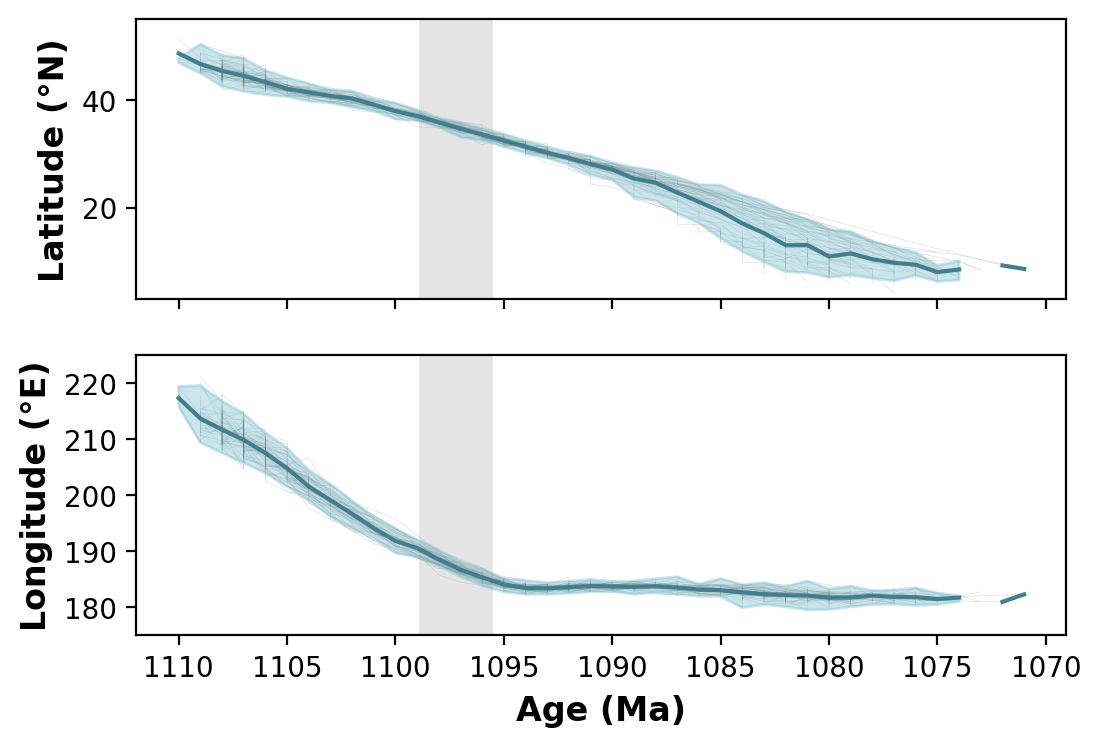

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(6,4), sharex=True)

# Set Axis Labels
axes[0].set_ylabel(r'Latitude (°N)', fontweight ='bold', fontsize = 12)
axes[1].set_ylabel(r'Longitude (°E)', fontweight ='bold', fontsize = 12)
axes[1].set_xlabel(r'Age (Ma)', fontweight ='bold', fontsize = 12)

# LATITUDES 
for run, df_run in df_RM_ensemble_50.groupby('run'):
    axes[0].plot(df_run.effective_age.tolist(), df_run.plat.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, alpha=0.2)

# axes[0].plot(df_run.effective_age.tolist(), df_run.plat.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, label = 'Moving Average realization')
axes[0].fill_between(ensemble_PC_eff_age.X, ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[2], 
                     ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[3], 
                     color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
# axes[0].scatter(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[1],color="#314B54", s = 15,  label = 'Principal component of the age ensemble')  
axes[0].plot(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[1],color="#427E8C")  

# LONGITUDES     
for run, df_run in df_RM_ensemble_50.groupby('run'):
    axes[1].plot(df_run.effective_age.tolist(), df_run.plon.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, alpha=0.2)
# axes[1].plot(df_run.effective_age.tolist(), df_run.plon.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, label = 'Moving Average realization')
axes[1].fill_between(ensemble_PC_eff_age.X, ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[0], 
                     ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[1], 
                     color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
# axes[1].scatter(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[0]%360,color="#314B54", s = 15,  label = 'Principal component of the age ensemble')
axes[1].plot(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[0]%360,color="#427E8C")  

axes[0].fill_between([1095.5, 1098.9], [3,3], [55, 55], color='grey', lw=0, alpha=0.2, zorder=0)
axes[0].set_ylim(3, 55)

axes[1].fill_between([1095.5, 1098.9], [175,175], [225, 225], color='grey', lw=0, alpha=0.2, zorder=0)
axes[1].set_ylim(175, 225)
plt.gca().invert_xaxis()
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_APW_components.pdf', bbox_inches='tight')


## draw example site stratigraphy with age model

In [54]:
# let's show the decoupled VGP age and stratigraphy
NSVG_SW_ultimate_ensemble = pseudo_ultimate_sites_ensemble_w_MAD[pseudo_ultimate_sites_ensemble_w_MAD['study'] == 'North Shore Volcanic Group (upper SW sequence)'].reset_index(drop=True)    
NSVG_SW_ultimate_ensemble.head()

,study,site,height,age,dec,inc,slat,slon,spolarity,plon,plat,run
0,North Shore Volcanic Group (upper SW sequence),ns050,3622.424125,1096.674789,290.374187,46.244303,46.88286,268.08416,n,184.341447,33.286030,0.0
1,North Shore Volcanic Group (upper SW sequence),ns051,3809.431070,1096.674789,294.800323,40.929708,46.88497,268.08801,n,177.465183,33.600938,0.0
2,North Shore Volcanic Group (upper SW sequence),ns051,3809.431070,1096.674789,293.402704,41.269742,46.88497,268.08801,n,178.709620,32.813349,0.0
3,North Shore Volcanic Group (upper SW sequence),ns053,3430.871282,1096.674789,291.656368,42.767990,46.87654,268.06891,n,180.950824,32.367285,0.0
4,North Shore Volcanic Group (upper SW sequence),ns055,3051.536951,1096.674789,285.193916,36.136347,46.87575,268.04751,n,181.503511,24.746428,0.0


In [55]:
Normalize_NSVG_SW_ensemble = Normalize(vmin=NSVG_SW_ensemble['age'].min(), vmax=NSVG_SW_ensemble['age'].max())
cmap_NSVG_SW_ensemble = plt.cm.viridis_r

plt.figure(figsize=(2, 10))
for run in NSVG_SW_ultimate_ensemble['run'].unique()[:1]:
    this_df = NSVG_SW_ultimate_ensemble[NSVG_SW_ultimate_ensemble['run'] == run]
    this_df.sort_values('height', inplace=True)
    for i in range(this_df.shape[0]-1):
        plt.plot([this_df['age'].iloc[i], this_df['age'].iloc[i+1]], [this_df['height'].iloc[i], this_df['height'].iloc[i+1]], 
                 color = cmap_NSVG_SW_ensemble(Normalize_NSVG_SW_ensemble(this_df['age'].iloc[i]/2 + this_df['age'].iloc[i+1]/2)), marker='o', lw=0.6, alpha=0.4)
# plt.scatter(NSVG_SW_ultimate_ensemble['age'][:87], NSVG_SW_ultimate_ensemble['height'][:87], 
#             color = cmap_NSVG_SW_ensemble(Normalize_NSVG_SW_ensemble(NSVG_SW_ultimate_ensemble['age'][:87])), alpha=0.6)
plt.xlim(1093.5, 1097.5)
# plt.ylim(0, 9000)
plt.xticks([1094, 1095, 1096, 1097], rotation=45, visible=True)
plt.yticks([0, 2000, 4000, 6000, 8000], [0, 2000, 4000, 6000, 8000], visible=0)
plt.gca().invert_xaxis()
# ax.tick_params(axis='both', which='both', length=5, labelsize=10)
plt.xlabel('Age (Ma)', fontsize=12)
# plt.ylabel('Height (m)', fontsize=12)
# plt.savefig('../figure/Keweenawan_NSVG_SW_with_age_model.pdf', bbox_inches='tight', transparent=False)
plt.show()

NameError: name 'NSVG_SW_ensemble' is not defined

## APWP

In [ ]:
apwp_eff = {'Age': ensemble_PC_eff_age.X,
           'Plat': ensemble_PC_eff_age.PC(quantile)[1],
           'Plon': ensemble_PC_eff_age.PC(quantile)[0],
           'Theta 95': ensemble_PC_eff_age.PC(quantile)[2],
           'max lat': ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[3],
           'min lat': ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[2],
           'max lon': ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[1],
           'min lon': ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[0],           
          }
df_apwp_eff = pd.DataFrame(apwp_eff)
# df_apwp_eff.to_csv('./apwp_output/Keweenawan_track_VGP_APWP.csv', index = False)

In [ ]:
df_apwp_eff